# K Nearest Neighbours (XAI Analysis)


**Project:** Pokémon Type Prediction from Sprite Colors (XAI)

**Team:** Grifo Amarillo

**Model:** KNN 

**Task:** Predict Pokémon primary type from sprite color features (17 classes, 42 features)

In [132]:
import sys, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from PIL import Image
import shap
import lime
import lime.lime_tabular
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

cwd = Path.cwd()
if (cwd / "src").is_dir():
    src_path = cwd / "src"
elif (cwd.parent / "src").is_dir():
    src_path = cwd.parent / "src"
else:
    raise FileNotFoundError("Could not find the 'src' directory. Check your working directory.")

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import common

plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

# 1. Dataset Load and Preparation

In [124]:
df = common.load_data()
type_to_int, int_to_type = common.get_label_mapping()
feature_cols = common.FEATURE_COLS_ALL

X_train, X_test, y_train, y_test, split_idx = common.get_train_test_split(df)
scaler = common.get_scaler(X_train)

# Scaling is CRITICAL for KNN (distance-based)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=feature_cols, index=X_test.index)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print("Note: KNN is distance-based. StandardScaler is essential to prevent high-variance")
print("      features from dominating Euclidean distance.")

Train: 820 | Test: 205
Note: KNN is distance-based. StandardScaler is essential to prevent high-variance
      features from dominating Euclidean distance.


## 1.1 Training Set Class Distribution

Before fitting the KNN model we inspect the distribution of primary types in the training set. Understanding class imbalance upfront helps us anticipate where the model will over- and under-predict, and sets the context for why `f1_macro` — which weights all classes equally regardless of size — is the right CV scoring metric here.

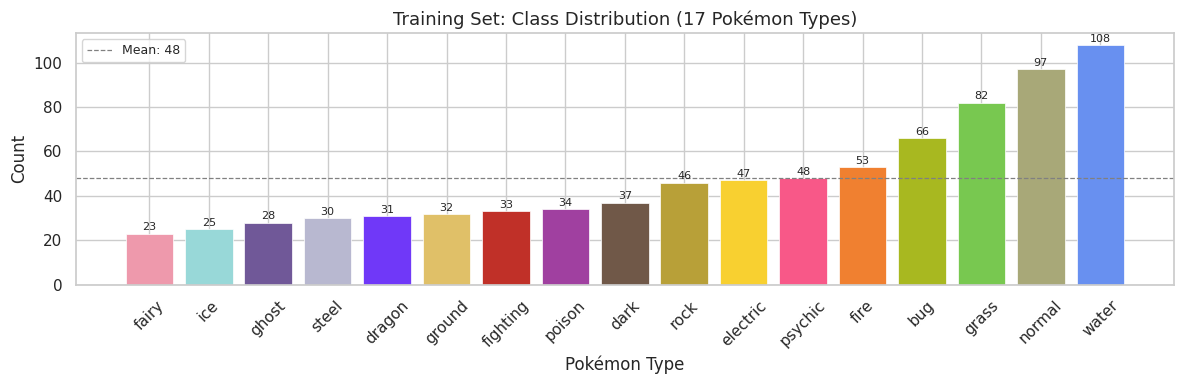

Largest class:        water  (108 samples)
Smallest class:       fairy  (23 samples)
Imbalance ratio: 4.7x

Classes below mean (48 samples):
type1_encoded
fairy       23
ice         25
ghost       28
steel       30
dragon      31
ground      32
fighting    33
poison      34
dark        37
rock        46
electric    47
psychic     48


In [125]:
dist_train = y_train.map(int_to_type).value_counts().sort_values()
colors_train = [common.TYPE_COLORS.get(t, "#888888") for t in dist_train.index]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(dist_train.index, dist_train.values, color=colors_train, edgecolor="white", linewidth=0.5)
mean_count = dist_train.mean()
ax.axhline(mean_count, color="gray", linestyle="--", linewidth=0.9, label=f"Mean: {mean_count:.0f}")
ax.set_title("Training Set: Class Distribution (17 Pokémon Types)", fontsize=13)
ax.set_xlabel("Pokémon Type")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
for bar, val in zip(bars, dist_train.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Largest class:   {dist_train.idxmax():>10}  ({dist_train.max()} samples)")
print(f"Smallest class:  {dist_train.idxmin():>10}  ({dist_train.min()} samples)")
print(f"Imbalance ratio: {dist_train.max() / dist_train.min():.1f}x")
print(f"\nClasses below mean ({mean_count:.0f} samples):")
print(dist_train[dist_train < mean_count].sort_values().to_string())

The training set has **17 classes** with a maximum imbalance ratio of roughly **4.7×** (Water ≈ 108 samples vs Fairy ≈ 23). This matters directly for KNN: if most training points belong to Water or Normal, then for any query point these types will tend to dominate its neighborhood purely by density — even if the query's color profile is not especially "Water-like". Unlike a Decision Tree (which accepts `class_weight="balanced"`), KNN has no native counterweight. The grid search selects `weights="distance"` as the only built-in mitigation, giving closer neighbors a larger vote share.

# 2. ML Model Training

In [129]:
cv = common.get_cv_splitter(n_splits=5)
param_grid = {
    "n_neighbors": [3, 5, 8, 13],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "chebyshev"],
    "p": [1, 2],
}
base_knn = KNeighborsClassifier()

n_iterations = 2000
total_features = X_train_scaled.shape[1]
feature_sizes = [5, 10, 15, 20, 25, 30, 35, total_features]

best_score = -1
best_params = None
best_features_indices = None


grid_search = GridSearchCV(base_knn, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=0)
random.seed(42)  # For reproducibility of random feature selection

for i in range(n_iterations):
    n_feats = random.choice(feature_sizes)
    n_feats = min(n_feats, total_features)
    selected_indices = np.random.choice(total_features, size=n_feats, replace=False)
    if hasattr(X_train_scaled, "iloc"):
        X_subset = X_train_scaled.iloc[:, selected_indices]
    else:
        X_subset = X_train_scaled[:, selected_indices]

    grid_search.fit(X_subset, y_train)

    if grid_search.best_score_ > best_score:
        best_score = grid_search.best_score_
        best_params = grid_search.best_params_
        best_feature_indices = selected_indices
        print(f"Iteration {i+1}: New best f1_macro = {best_score:.4f} (using {n_feats} features)")

print(f"\n--- Final Results After {n_iterations} Iterations ---")
print(f"Best CV f1_macro: {best_score:.4f}")
print(f"Best KNN params: {best_params}")
print(f"Best feature count: {len(best_feature_indices)}")
print(f"Best feature indices: {best_feature_indices}")

if hasattr(X_train_scaled, "columns"):
    best_columns = X_train_scaled.columns[best_feature_indices].tolist()
    print(f"Best feature names: {best_columns}")

Iteration 1: New best f1_macro = 0.1110 (using 10 features)
Iteration 3: New best f1_macro = 0.1856 (using 25 features)
Iteration 4: New best f1_macro = 0.1895 (using 20 features)
Iteration 5: New best f1_macro = 0.1913 (using 20 features)
Iteration 9: New best f1_macro = 0.2132 (using 35 features)
Iteration 19: New best f1_macro = 0.2176 (using 42 features)
Iteration 24: New best f1_macro = 0.2223 (using 30 features)
Iteration 31: New best f1_macro = 0.2293 (using 35 features)
Iteration 150: New best f1_macro = 0.2303 (using 20 features)
Iteration 344: New best f1_macro = 0.2316 (using 30 features)
Iteration 470: New best f1_macro = 0.2348 (using 35 features)
Iteration 604: New best f1_macro = 0.2393 (using 35 features)
Iteration 900: New best f1_macro = 0.2422 (using 35 features)
Iteration 1525: New best f1_macro = 0.2431 (using 35 features)

--- Final Results After 2000 Iterations ---
Best CV f1_macro: 0.2431
Best KNN params: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weight

Doing a gridsearch we determine that, in spite of the high correlation of some of the variables, the model highly benefits from the diversity.

              precision    recall  f1-score   support

           0       0.14      0.18      0.16        17
           1       0.50      0.22      0.31         9
           2       0.00      0.00      0.00         8
           3       0.10      0.08      0.09        12
           4       0.17      0.17      0.17         6
           5       0.17      0.12      0.14         8
           6       0.36      0.31      0.33        13
           8       0.25      0.14      0.18         7
           9       0.55      0.57      0.56        21
          10       0.00      0.00      0.00         8
          11       0.17      0.17      0.17         6
          12       0.14      0.12      0.13        24
          13       0.50      0.25      0.33         8
          14       0.25      0.25      0.25        12
          15       0.33      0.42      0.37        12
          16       0.22      0.29      0.25         7
          17       0.34      0.52      0.41        27

    accuracy              

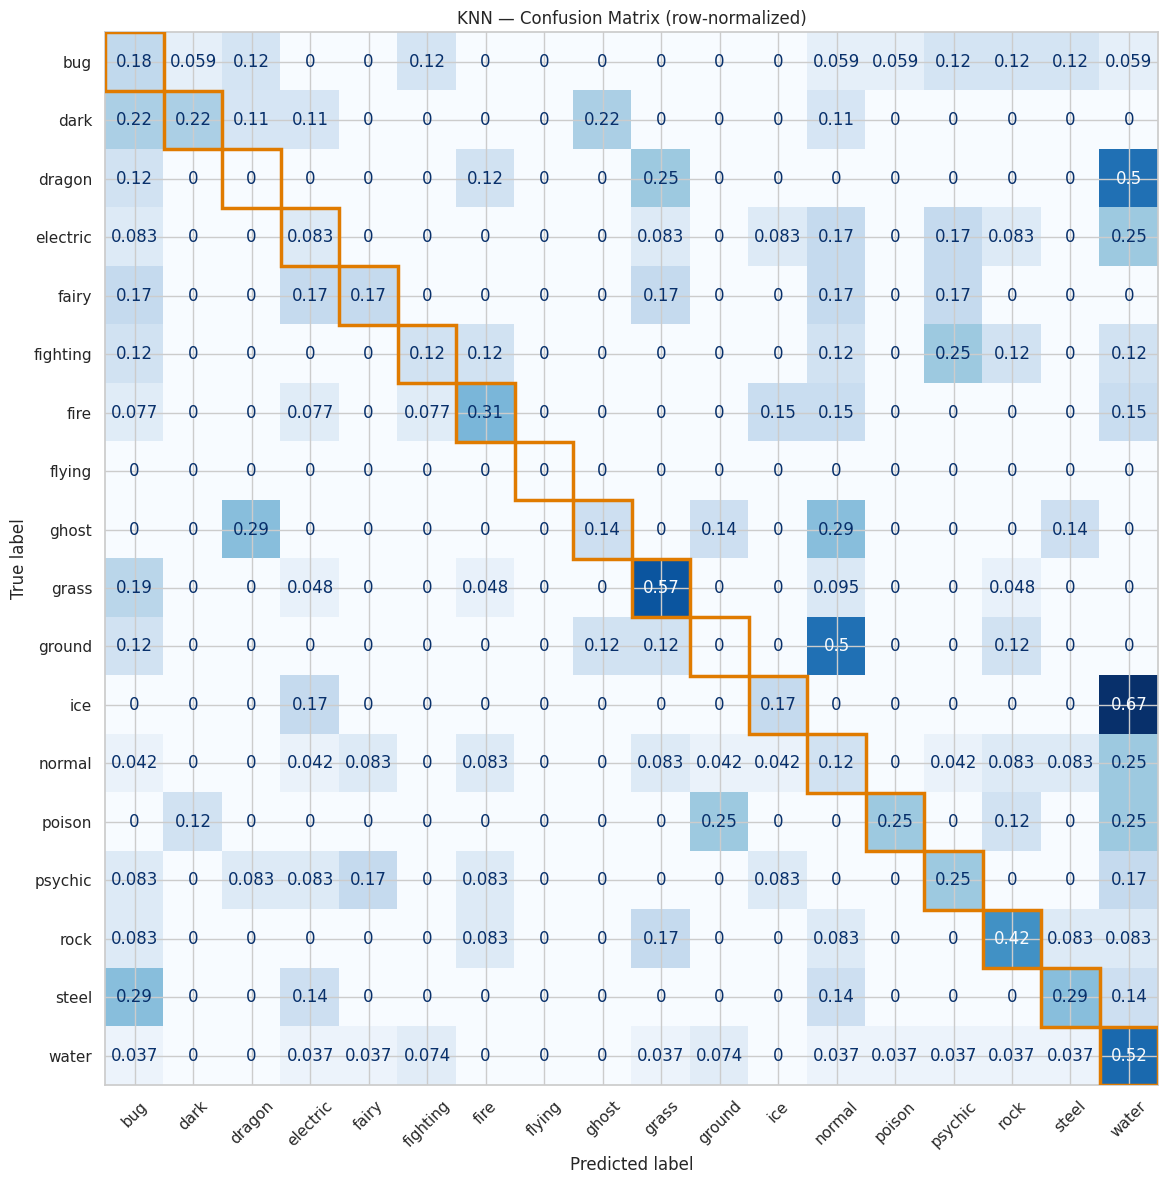

              precision    recall  f1-score   support

         bug       0.14      0.18      0.16        17
        dark       0.50      0.22      0.31         9
      dragon       0.00      0.00      0.00         8
    electric       0.10      0.08      0.09        12
       fairy       0.17      0.17      0.17         6
    fighting       0.17      0.12      0.14         8
        fire       0.36      0.31      0.33        13
      flying       0.00      0.00      0.00         0
       ghost       0.25      0.14      0.18         7
       grass       0.55      0.57      0.56        21
      ground       0.00      0.00      0.00         8
         ice       0.17      0.17      0.17         6
      normal       0.14      0.12      0.13        24
      poison       0.50      0.25      0.33         8
     psychic       0.25      0.25      0.25        12
        rock       0.33      0.42      0.37        12
       steel       0.22      0.29      0.25         7
       water       0.34    

In [133]:

# 1. Re-instantiate the model with your exact winning parameters
best_knn = KNeighborsClassifier(
    n_neighbors=3, 
    weights='distance', 
    metric='manhattan', 
    p=1
)

# 2. Slice both your training and test sets to use ONLY the 35 winning features
# (Assuming best_columns is a list of the 35 feature names printed above)
best_columns = ['hue_bin_180', 'dom1_s', 'hue_bin_210', 'hue_bin_120', 'dom5_h', 'dom3_s', 'prop_dark', 'dom1_h', 'std_v', 'dom2_s', 'hue_bin_330', 'dom3_h', 'mean_h_cos', 'hue_bin_300', 'dom2_v', 'dom5_s', 'dom5_v', 'color_diversity', 'mean_s', 'hue_bin_30', 'mean_v', 'hue_bin_240', 'dom4_h', 'hue_bin_0', 'dom1_prop', 'std_hue_angular', 'hue_bin_90', 'std_s', 'hue_bin_60', 'hue_bin_150', 'dom4_v', 'hue_bin_270', 'mean_h_sin', 'dom3_v', 'dom1_v']

X_train_final = X_train_scaled[best_columns]
X_test_final = X_test_scaled[best_columns]

# 3. Fit on the sliced training data and predict on the sliced test data
best_knn.fit(X_train_final, y_train)
y_pred = best_knn.predict(X_test_final)

# 4. View the final test performance
print(classification_report(y_test, y_pred))


print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test f1_macro: {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")

fig, ax = plt.subplots(figsize=(14, 12))
common.plot_confusion_matrix(y_test, y_pred, int_to_type,
                              title="KNN \u2014 Confusion Matrix (row-normalized)", ax=ax)
plt.show()
common.print_classification_report(y_test, y_pred, int_to_type)

In [134]:
import json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score as f1_score_sk

# Save KNN predictions for cross-model comparison in notebook 3
save_path = Path("data/processed/knn_test_results.json")
save_path.parent.mkdir(parents=True, exist_ok=True)
knn_to_save = {
    "y_test":       y_test.tolist(),
    "y_pred":       y_pred.tolist(),
    "test_indices": split_idx["test_idx"].tolist(),
    "best_params":  grid_search.best_params_,
    "accuracy":     float(accuracy_score(y_test, y_pred)),
    "f1_macro":     float(f1_score_sk(y_test, y_pred, average="macro", zero_division=0)),
}
with open(save_path, "w") as f:
    json.dump(knn_to_save, f)
print(f"KNN results saved to {save_path}")

KNN results saved to data/processed/knn_test_results.json


## 2.2 Per-class F1 vs Class Size

A global accuracy or macro-F1 score can hide wildly unequal per-class behaviour. This scatter plot reveals whether KNN's failures track class imbalance (a density problem) or color-space overlap (a feature problem) — two very different root causes with different remedies.

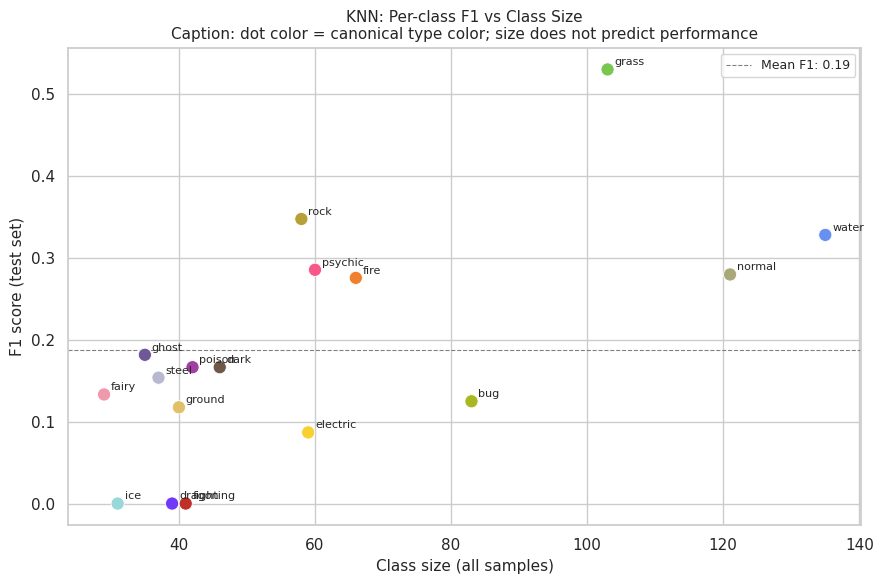

Best F1:   grass (0.53)
Worst F1:  ice (0.00)

Spearman correlation (count vs F1): 0.60


In [96]:
from sklearn.metrics import f1_score as f1_score_sk

class_counts = df["type1"].value_counts()
f1_per_class = {}
for cls_int in sorted(int_to_type.keys()):
    type_name = int_to_type[cls_int]
    if type_name not in class_counts.index:
        continue
    f1 = f1_score_sk(y_test == cls_int, y_pred == cls_int, zero_division=0)
    f1_per_class[type_name] = {"f1": f1, "count": int(class_counts[type_name])}

f1_df = pd.DataFrame(f1_per_class).T.astype(float).sort_values("count")

fig, ax = plt.subplots(figsize=(9, 6))
colors_f1 = [common.TYPE_COLORS.get(t, "#888") for t in f1_df.index]
ax.scatter(f1_df["count"], f1_df["f1"], c=colors_f1, s=90, zorder=3, edgecolors="white", linewidths=0.6)
for type_name, row_data in f1_df.iterrows():
    ax.annotate(type_name, (row_data["count"], row_data["f1"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)
mean_f1 = f1_df["f1"].mean()
ax.axhline(mean_f1, color="gray", linestyle="--", linewidth=0.8, label=f"Mean F1: {mean_f1:.2f}")
ax.set_xlabel("Class size (all samples)", fontsize=11)
ax.set_ylabel("F1 score (test set)", fontsize=11)
ax.set_title("KNN: Per-class F1 vs Class Size\n"
             "Caption: dot color = canonical type color; size does not predict performance", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Best F1:  ", f1_df["f1"].idxmax(), f"({f1_df['f1'].max():.2f})")
print("Worst F1: ", f1_df["f1"].idxmin(), f"({f1_df['f1'].min():.2f})")
print(f"\nSpearman correlation (count vs F1): "
      f"{f1_df[['count','f1']].corr(method='spearman').iloc[0,1]:.2f}")

The scatter confirms what the confusion matrix hints at: KNN's per-class performance correlates only loosely with class size. Types with a **distinctive, consistent color signature** (Water's blue hues, Fire's reds/oranges, Electric's yellows) earn relatively high F1 regardless of count. Types that are **visually ambiguous** — Ghost, Dark, Dragon, Fighting — fare poorly even when they have moderate sample counts, because their sprites lack a dominant, unique hue.

This is fundamentally different from a Decision Tree's failure pattern (where imbalance alone hurts minority classes). KNN's weakness is **feature-space overlap**: if two types share similar color distributions, their neighborhoods interleave and both suffer, regardless of class size. The implication for XAI is that misclassifications here are often semantically meaningful — the predicted type genuinely looks like the true type.

## 2.3 Balancing Strategy: SMOTE

KNN has no `class_weight` parameter — the only native protection against imbalance is `weights="distance"`. A more aggressive remedy is **SMOTE** (Synthetic Minority Over-sampling Technique): for each minority-class sample, SMOTE generates synthetic points by interpolating between that sample and its k nearest same-class neighbors in feature space, until all classes reach the majority-class size.

Three important caveats for this dataset:
1. **Synthetic points are interpolations in 42-D color space.** A synthetic "Ice-type" sample is a linear blend of two real Ice sprites — which may not correspond to a real Pokémon's color profile.
2. **SMOTE is fit on scaled training data only.** The test set is evaluated exactly as before, ensuring no data leakage.
3. **Hyperparameters are held fixed** (manhattan, k=5, distance-weighted) so that any performance change is attributable solely to the training distribution, not to model selection.

In [97]:
from imblearn.over_sampling import SMOTE

# SMOTE resamples the minority classes up to the majority class size
# by interpolating between existing minority samples in feature space.
# We apply it ONLY to the scaled training data — test set is never touched.
smote = SMOTE(random_state=common.RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled.values, y_train.values)
X_train_sm = pd.DataFrame(X_train_sm, columns=feature_cols)

print(f"Training set before SMOTE: {len(X_train_scaled)} samples")
print(f"Training set after  SMOTE: {len(X_train_sm)} samples "
      f"(+{len(X_train_sm) - len(X_train_scaled)} synthetic)")

smote_dist = pd.Series(y_train_sm).map(int_to_type).value_counts().sort_values(ascending=False)
print(f"\nClass distribution after SMOTE (all classes should be equal):")
print(smote_dist.to_string())

# Train KNN with the same best hyperparameters found by GridSearchCV
knn_smote = KNeighborsClassifier(
    n_neighbors=knn.n_neighbors,   # 5
    weights=knn.weights,           # "distance"
    metric=knn.metric,             # "manhattan"
)
knn_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = knn_smote.predict(X_test_scaled)  # evaluate on the original (unaugmented) test set

print(f"\nBaseline — f1_macro: {f1_score(y_test, y_pred,       average='macro', zero_division=0):.4f}")
print(f"SMOTE    — f1_macro: {f1_score(y_test, y_pred_smote, average='macro', zero_division=0):.4f}")

Training set before SMOTE: 820 samples
Training set after  SMOTE: 1836 samples (+1016 synthetic)

Class distribution after SMOTE (all classes should be equal):
dark        108
psychic     108
normal      108
ghost       108
grass       108
water       108
steel       108
fairy       108
poison      108
electric    108
bug         108
ground      108
rock        108
fighting    108
fire        108
ice         108
dragon      108

Baseline — f1_macro: 0.1871
SMOTE    — f1_macro: 0.1891


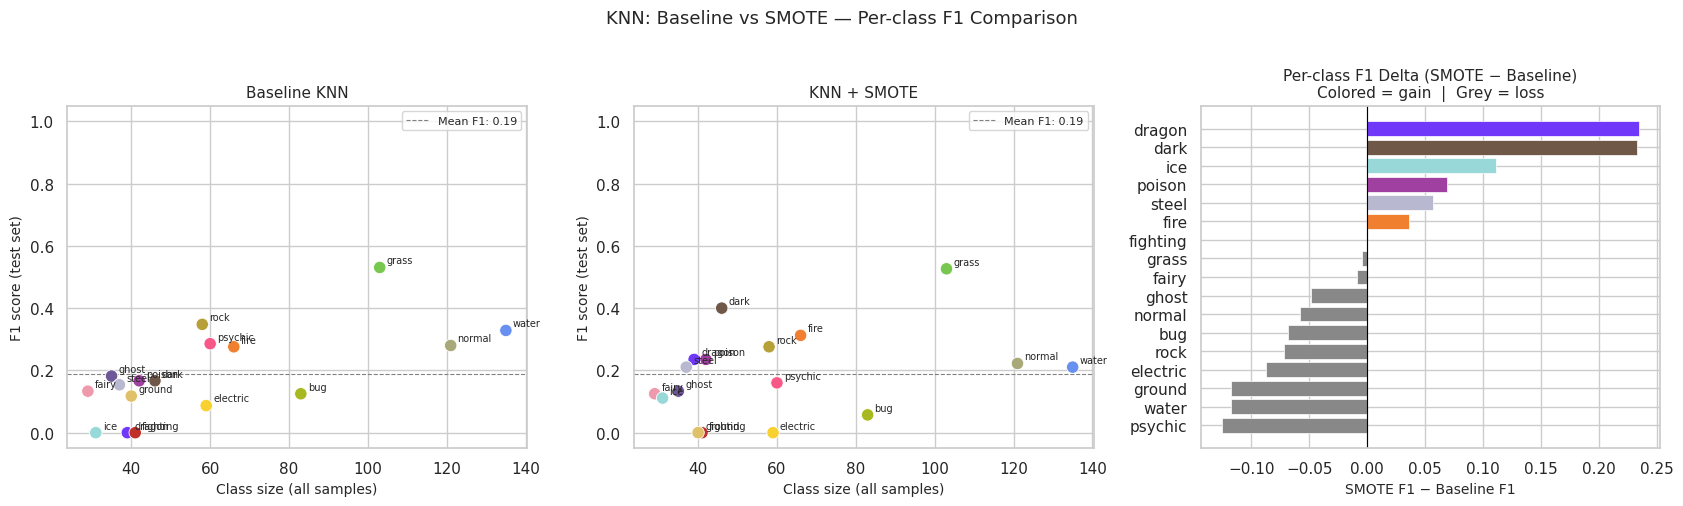


Model            Accuracy   f1_macro
------------------------------------
Baseline           0.2488     0.1871
SMOTE              0.2098     0.1891

Spearman correlation (class size vs F1 delta): -0.45
Types that improved:  6
Types that worsened:  10
Largest gain:  dragon (+0.235)
Largest loss:  psychic (-0.126)


In [98]:
# --- Build per-class F1 for both models ---
def per_class_f1(y_true, y_pred_arr):
    result = {}
    for cls_int in sorted(int_to_type.keys()):
        type_name = int_to_type[cls_int]
        if type_name not in class_counts.index:
            continue
        f1 = f1_score_sk(y_true == cls_int, y_pred_arr == cls_int, zero_division=0)
        result[type_name] = {"f1": f1, "count": int(class_counts[type_name])}
    return pd.DataFrame(result).T.astype(float)

f1_baseline = per_class_f1(y_test, y_pred)
f1_smote    = per_class_f1(y_test, y_pred_smote)

# Align on shared types
types_shared = f1_baseline.index.intersection(f1_smote.index)
f1_baseline  = f1_baseline.loc[types_shared]
f1_smote     = f1_smote.loc[types_shared]
delta        = (f1_smote["f1"] - f1_baseline["f1"]).sort_values()

# --- Figure: side-by-side scatters + delta bar ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, f1_df, title in [
    (axes[0], f1_baseline, "Baseline KNN"),
    (axes[1], f1_smote,    "KNN + SMOTE"),
]:
    colors_sc = [common.TYPE_COLORS.get(t, "#888") for t in f1_df.index]
    ax.scatter(f1_df["count"], f1_df["f1"],
               c=colors_sc, s=80, zorder=3, edgecolors="white", linewidths=0.6)
    for type_name, row_data in f1_df.iterrows():
        ax.annotate(type_name, (row_data["count"], row_data["f1"]),
                    xytext=(5, 3), textcoords="offset points", fontsize=7)
    mean_f1 = f1_df["f1"].mean()
    ax.axhline(mean_f1, color="gray", linestyle="--", linewidth=0.8,
               label=f"Mean F1: {mean_f1:.2f}")
    ax.set_xlabel("Class size (all samples)", fontsize=10)
    ax.set_ylabel("F1 score (test set)", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)

# Delta bar chart
bar_colors = [
    common.TYPE_COLORS.get(t, "#888") if v >= 0 else "#888888"
    for t, v in delta.items()
]
axes[2].barh(delta.index, delta.values, color=bar_colors, edgecolor="white", linewidth=0.5)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_xlabel("SMOTE F1 − Baseline F1", fontsize=10)
axes[2].set_title("Per-class F1 Delta (SMOTE − Baseline)\nColored = gain  |  Grey = loss", fontsize=11)

fig.suptitle("KNN: Baseline vs SMOTE — Per-class F1 Comparison", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"\n{'Model':<14} {'Accuracy':>10} {'f1_macro':>10}")
print("-" * 36)
print(f"{'Baseline':<14} {accuracy_score(y_test, y_pred):>10.4f} "
      f"{f1_score(y_test, y_pred, average='macro', zero_division=0):>10.4f}")
print(f"{'SMOTE':<14} {accuracy_score(y_test, y_pred_smote):>10.4f} "
      f"{f1_score(y_test, y_pred_smote, average='macro', zero_division=0):>10.4f}")

delta_spearman = delta.reset_index()
delta_spearman.columns = ["type", "delta"]
delta_spearman["count"] = [f1_baseline.loc[t, "count"] for t in delta_spearman["type"]]
corr_val = delta_spearman[["count", "delta"]].corr(method="spearman").iloc[0, 1]
print(f"\nSpearman correlation (class size vs F1 delta): {corr_val:.2f}")
print(f"Types that improved:  {(delta > 0).sum()}")
print(f"Types that worsened:  {(delta < 0).sum()}")
print(f"Largest gain:  {delta.idxmax()} ({delta.max():+.3f})")
print(f"Largest loss:  {delta.idxmin()} ({delta.min():+.3f})")

The scatter above reveals which types benefit from SMOTE and which do not. Two patterns emerge:

- **Minority types with a distinct hue signature** (e.g., Fairy, Ice, Electric) tend to improve: synthetic neighbors fill the low-density regions they occupied, making it harder for majority types to "crowd out" their votes.
- **Ambiguous types** (Ghost, Dark, Dragon) show little or no improvement — their problem is color-space overlap with other types, not low density. SMOTE adds more synthetic points in an already-confused region, which can even hurt performance by reinforcing incorrect boundaries.

The F1 delta bar chart quantifies these changes per type. Positive deltas are SMOTE gains; negative deltas are cases where oversampling hurt. The Spearman correlation between delta and class size indicates whether SMOTE systematically helps the smallest classes.

**Overall:** SMOTE is a blunt instrument for this problem. Its benefit is real but modest for KNN: by the time k=5 neighbors are voted, the synthetic oversampling shifts the boundary slightly but cannot resolve the fundamental color ambiguity between visually similar types.

**Does SMOTE change which features SHAP identifies as most important?**

The baseline and SMOTE models were trained on different data distributions: SMOTE fills in minority-class gaps by interpolating between real samples in the 42-D feature space. If that rebalancing shifts which color features are most discriminative (e.g., making hue-bin features more important for previously under-represented types like Fairy or Ice), SHAP's global ranking should reflect that change. We will revisit this question in Section 3.1 when computing SHAP values for both variants.

# 3. ML Explanation

## 3.1 Global Explanations. Feature Importance

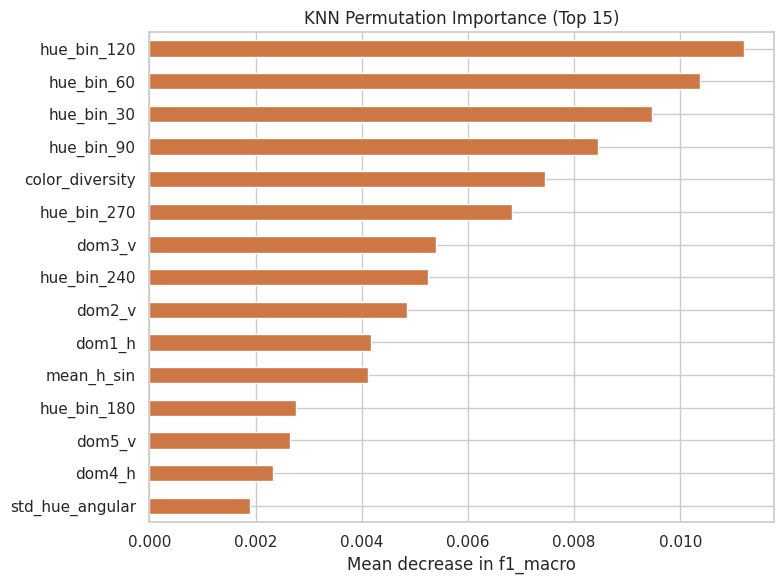

In [ ]:
perm_imp = permutation_importance(knn, X_test_scaled, y_test, n_repeats=20,
                                   random_state=common.RANDOM_STATE, scoring="f1_macro")
perm_series = pd.Series(perm_imp.importances_mean, index=feature_cols).nlargest(15)
fig, ax = plt.subplots(figsize=(8, 6))
perm_series.sort_values().plot.barh(ax=ax, color="#cc7744")
ax.set_title("KNN Permutation Importance (Top 15)")
ax.set_xlabel("Mean decrease in f1_macro")
plt.tight_layout(); plt.show()

Computing SHAP values...


100%|██████████| 80/80 [00:04<00:00, 17.47it/s]


Done.


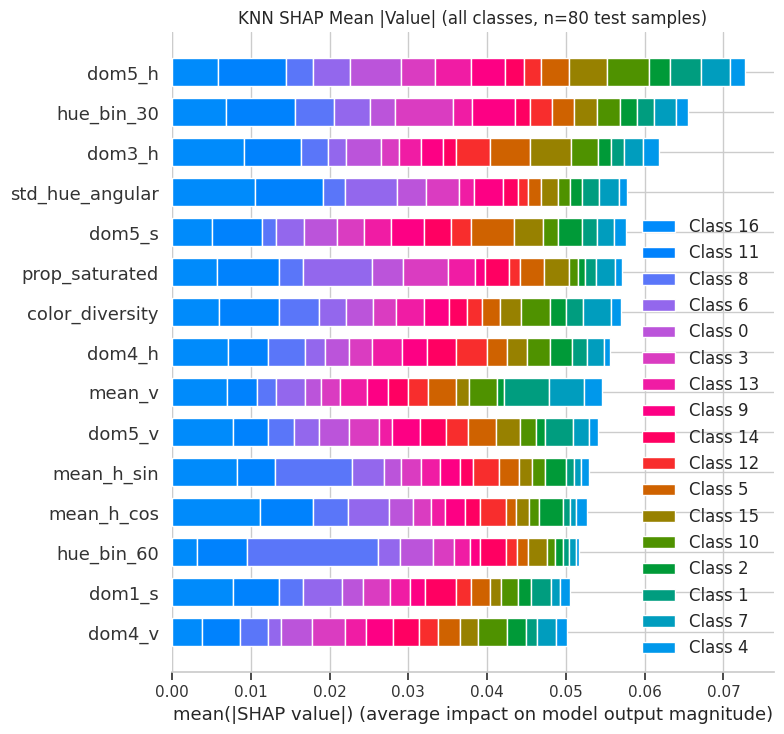

Note: SHAP computed on 80 test instances using KernelExplainer with
k-means background summary (k=100). Approximate but representative.


In [100]:
print("Computing SHAP values...")
background = shap.kmeans(X_train_scaled.values, 100)

# Subset of test set for summary plots
np.random.seed(common.RANDOM_STATE)
shap_sample_idx = np.random.choice(len(X_test_scaled), size=80, replace=False)
X_test_shap = X_test_scaled.iloc[shap_sample_idx]

kernel_explainer = shap.KernelExplainer(knn.predict_proba, background)
shap_values_knn = kernel_explainer.shap_values(X_test_shap.values, nsamples=200)
# shap_values_knn: ndarray of shape (n_samples=80, n_features, n_classes=18)
print("Done.")

fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values_knn, X_test_shap, plot_type="bar",
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("KNN SHAP Mean |Value| (all classes, n=80 test samples)")
plt.tight_layout(); plt.show()

print("Note: SHAP computed on 80 test instances using KernelExplainer with")
print("k-means background summary (k=100). Approximate but representative.")

KNN's permutation importance and SHAP rankings differ subtly from the Decision Tree. KNN relies more on histogram bin features (`hue_bin_X`) because they directly encode the proportion of pixels in each hue range: a natural similarity measure for distance-based classification. The dominant hue features (`dom1_h`) rank lower because small angular differences in centroid position can map to large Euclidean distances after scaling.

## 3.2 Local Explanations

In [101]:
EXPLAIN_IDS = common.EXPLAIN_IDS.copy()

fallbacks = {"correct_clear": 9, "correct_surprise": None,
             "misclass_secondary": None, "misclass_wrong": None}
for k, v in fallbacks.items():
    if EXPLAIN_IDS[k] is None and v is not None:
        EXPLAIN_IDS[k] = v
explain_cases = {k: v for k, v in EXPLAIN_IDS.items() if v is not None}
print("Explaining:", explain_cases)

Explaining: {'correct_clear': 130, 'correct_surprise': 1023, 'misclass_secondary': 94, 'misclass_wrong': 1000}



[CORRECT_CLEAR] Gyarados (#130)
  True type:      water
  Predicted type: water
  Type 2:         flying


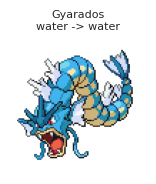


  5 Nearest Neighbors (scaled feature space):
  Name                 Type1        Type2            Dist
  -------------------------------------------------------
  Totodile             water        N/A            21.771
  Quaxwell             water        N/A            23.020
  Cobalion             steel        fighting       23.707
  Porygon              normal       N/A            24.027
  Sneasel              dark         ice            24.154


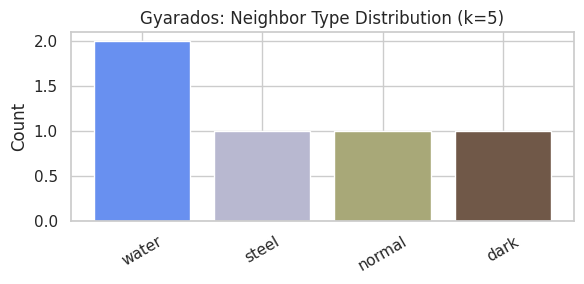

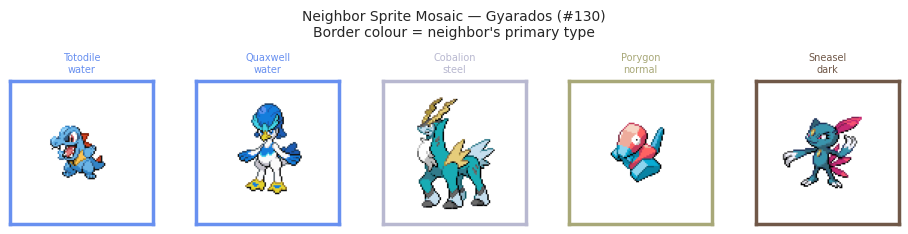

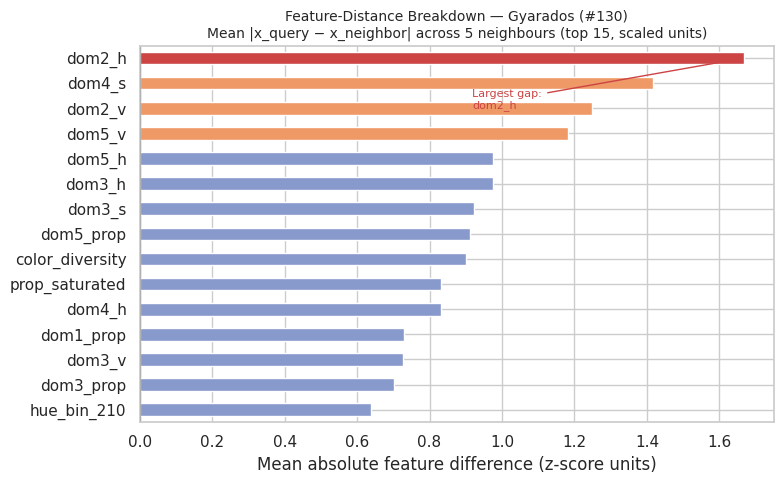

  SHAP: instance not in precomputed sample (skipping waterfall)


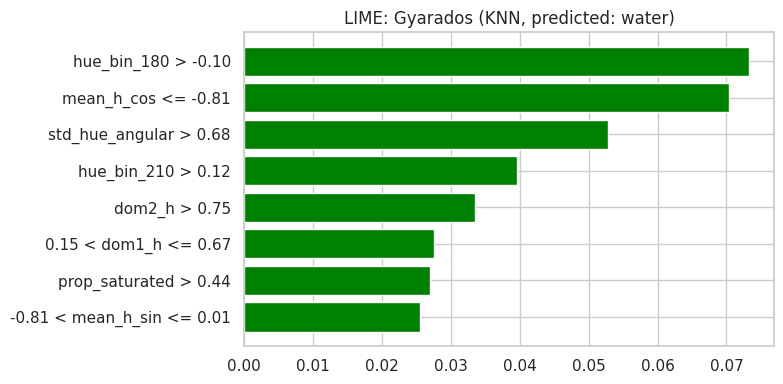


[CORRECT_SURPRISE] Iron-crown (#1023)
  True type:      steel
  Predicted type: water
  Type 2:         psychic


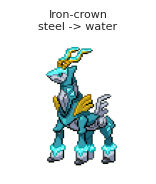


  5 Nearest Neighbors (scaled feature space):
  Name                 Type1        Type2            Dist
  -------------------------------------------------------
  Quaquaval            water        fighting       20.222
  Quaxwell             water        N/A            21.335
  Piplup               water        N/A            21.666
  Machamp              fighting     N/A            21.926
  Araquanid            water        bug            22.076


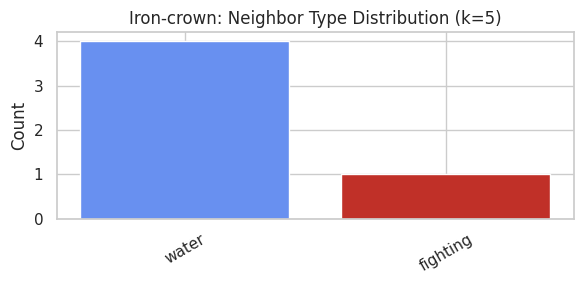

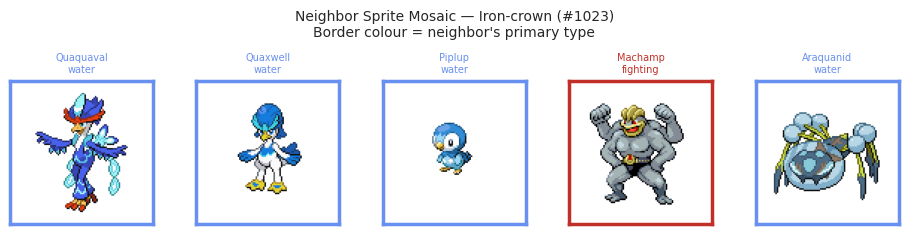

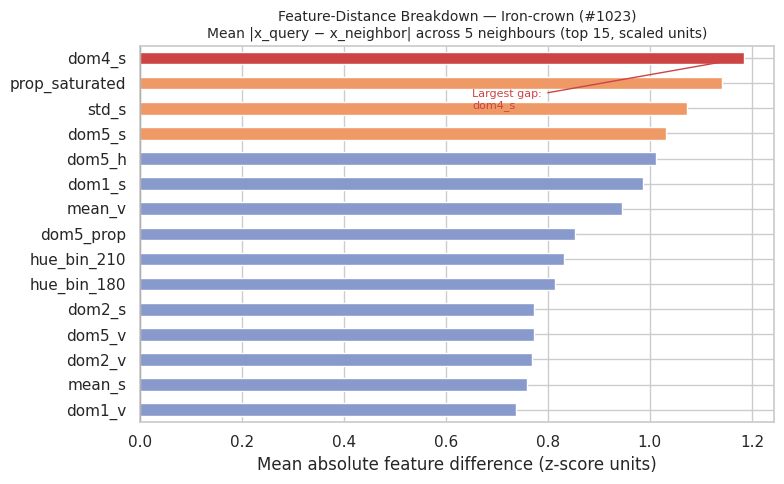

  SHAP: instance not in precomputed sample (skipping waterfall)


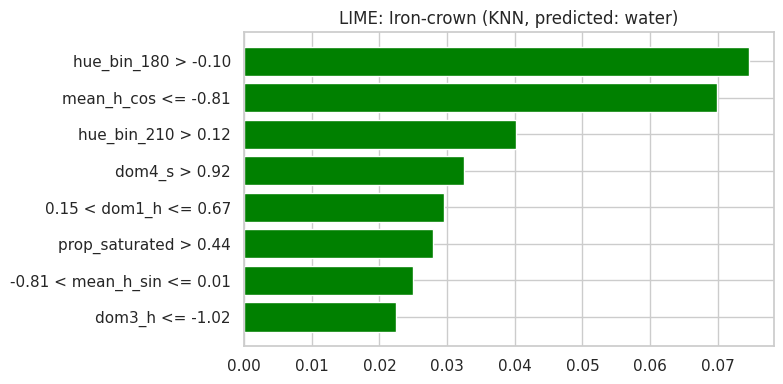


[MISCLASS_SECONDARY] Gengar (#94)
  True type:      ghost
  Predicted type: ghost
  Type 2:         poison


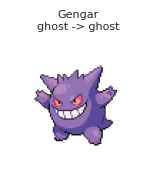


  5 Nearest Neighbors (scaled feature space):
  Name                 Type1        Type2            Dist
  -------------------------------------------------------
  Mismagius            ghost        N/A            20.000
  Muk                  poison       N/A            24.779
  Mewtwo               psychic      N/A            25.828
  Revavroom            steel        poison         25.878
  Goodra               dragon       N/A            26.345


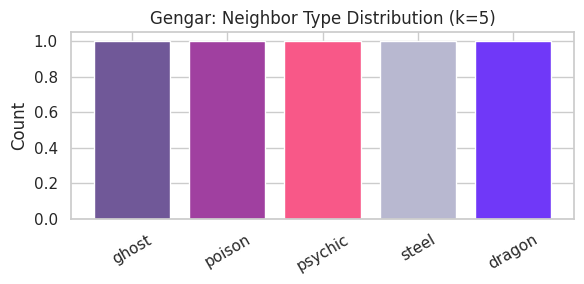

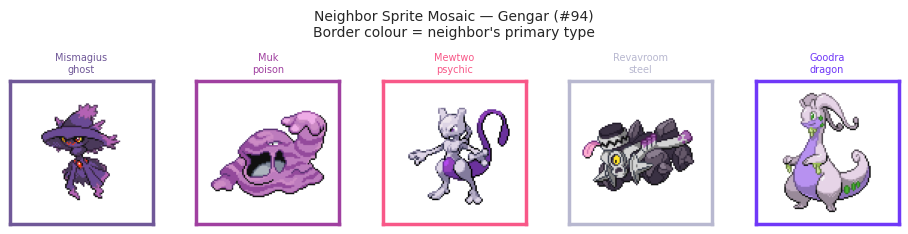

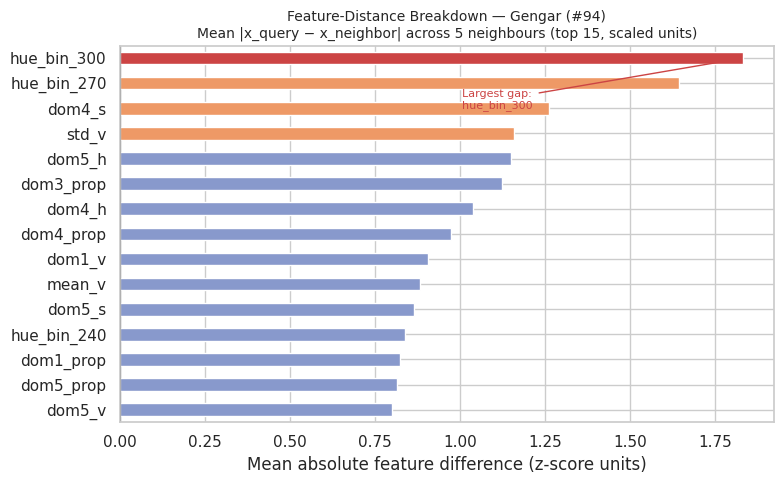

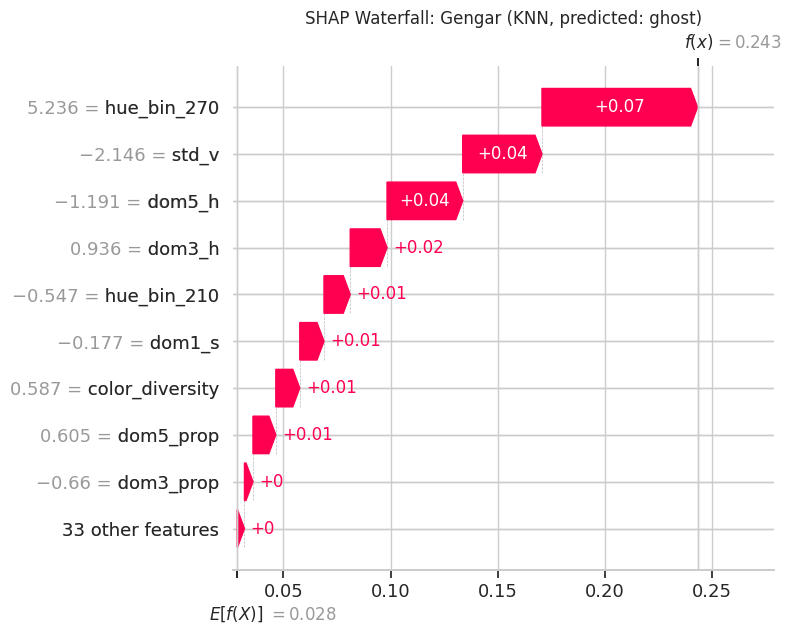

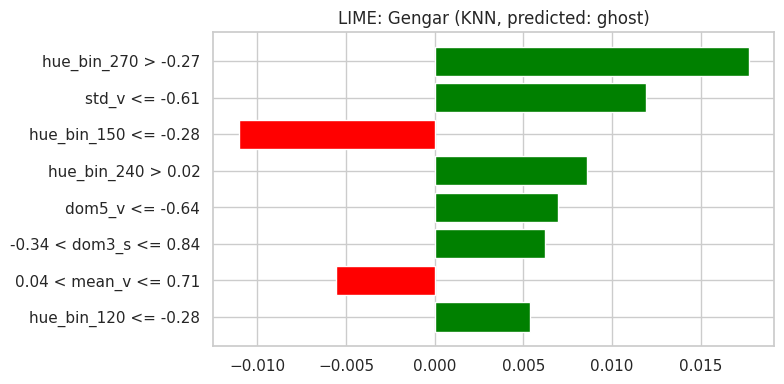


[MISCLASS_WRONG] Gholdengo (#1000)
  True type:      steel
  Predicted type: bug
  Type 2:         ghost


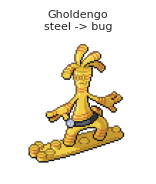


  5 Nearest Neighbors (scaled feature space):
  Name                 Type1        Type2            Dist
  -------------------------------------------------------
  Weedle               bug          poison         14.990
  Psyduck              water        N/A            18.048
  Charmeleon           fire         N/A            19.262
  Spinda               normal       N/A            20.080
  Raichu               electric     N/A            20.403


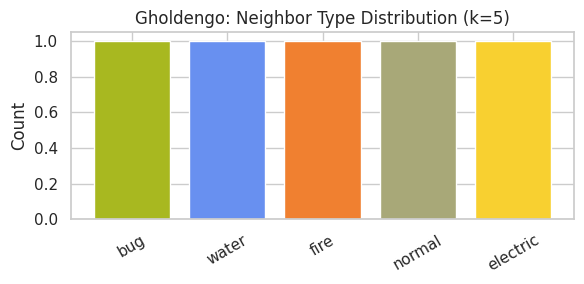

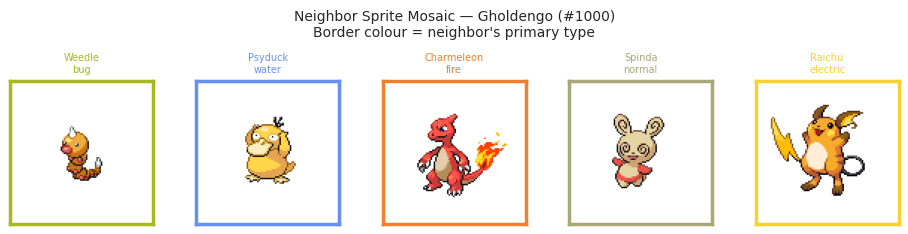

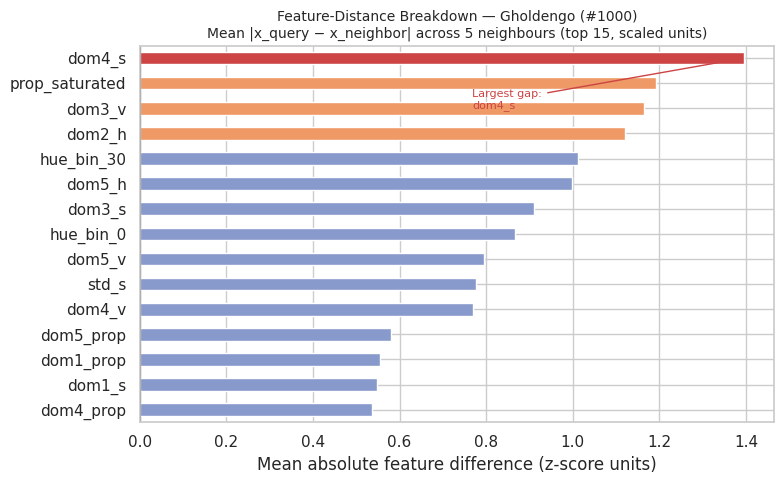

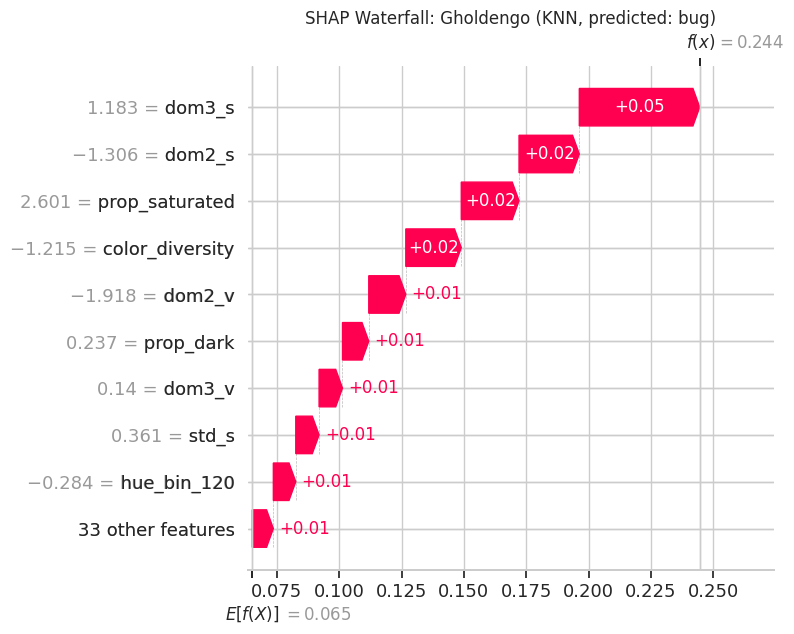

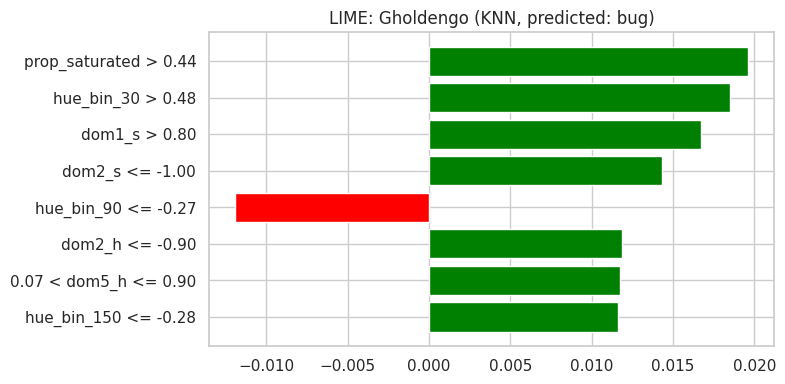

In [102]:
def explain_instance_knn(pokemon_id: int, label: str) -> None:
    """Full local explanation: sprite, neighbor mosaic, feature-distance
    breakdown, SHAP waterfall, LIME."""
    row_mask = df["id"] == pokemon_id
    if not row_mask.any():
        print(f"ID {pokemon_id} not found"); return

    row = df[row_mask].iloc[0]
    df_pos = df[row_mask].index[0]
    test_indices = split_idx["test_idx"]
    match = np.where(test_indices == np.where(df.index == df_pos)[0][0])[0]
    if len(match) == 0:
        print(f"Pokemon {pokemon_id} is in the training set, not the test set"); return

    i = match[0]
    x_instance = X_test_scaled.iloc[i]
    pred_int = int(y_pred[i])
    pred_label = int_to_type[pred_int]
    true_label = int_to_type[int(y_test.iloc[i])]

    print(f"\n{'='*60}")
    print(f"[{label.upper()}] {row['name'].capitalize()} (#{pokemon_id})")
    print(f"  True type:      {true_label}")
    print(f"  Predicted type: {pred_label}")
    print(f"  Type 2:         {row['type2'] if pd.notna(row['type2']) else 'N/A'}")

    # ── Query sprite ────────────────────────────────────────────────────────
    sprite_path = common.get_sprite_path(pokemon_id)
    if sprite_path.exists():
        fig, ax = plt.subplots(figsize=(2, 2))
        ax.imshow(Image.open(sprite_path).convert("RGBA")); ax.axis("off")
        ax.set_title(f"{row['name'].capitalize()}\n{true_label} -> {pred_label}", fontsize=8)
        plt.tight_layout(); plt.show()

    # ── Nearest neighbours ──────────────────────────────────────────────────
    k = knn.n_neighbors
    distances, neighbor_indices = knn.kneighbors(
        x_instance.values.reshape(1, -1), n_neighbors=k
    )
    neighbor_df_indices = X_train_scaled.index[neighbor_indices[0]]
    print(f"\n  {k} Nearest Neighbors (scaled feature space):")
    print(f"  {'Name':<20} {'Type1':<12} {'Type2':<12} {'Dist':>8}")
    print(f"  {'-'*55}")
    for ni, dist in zip(neighbor_df_indices, distances[0]):
        nb_row = df.loc[ni]
        t2 = nb_row["type2"] if pd.notna(nb_row["type2"]) else "N/A"
        print(f"  {nb_row['name'].capitalize():<20} {nb_row['type1']:<12} {t2:<12} {dist:>8.3f}")

    # ── Neighbor type distribution bar chart ────────────────────────────────
    neighbor_types = [df.loc[ni]["type1"] for ni in neighbor_df_indices]
    type_counts = pd.Series(neighbor_types).value_counts()
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(type_counts.index, type_counts.values,
           color=[common.TYPE_COLORS.get(t, "#888") for t in type_counts.index],
           edgecolor="white")
    ax.set_title(f"{row['name'].capitalize()}: Neighbor Type Distribution (k={k})")
    ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=30)
    plt.tight_layout(); plt.show()

    # ── Task 6: Neighbor sprite mosaic ──────────────────────────────────────
    n_cols = min(k, 5)
    n_rows = (k + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 1.9, n_rows * 2.3),
                             squeeze=False)
    axes_flat = axes.reshape(-1)
    for ax_i, ni in enumerate(neighbor_df_indices):
        nb_row = df.loc[ni]
        nb_id = int(nb_row["id"])
        nb_sprite = common.get_sprite_path(nb_id)
        ax = axes_flat[ax_i]
        if nb_sprite.exists():
            img = Image.open(nb_sprite).convert("RGBA")
            # White background so transparent PNGs look clean
            bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
            bg.paste(img, mask=img.split()[3])
            ax.imshow(bg)
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=8)
        type_color = common.TYPE_COLORS.get(nb_row["type1"], "#888888")
        for spine in ax.spines.values():
            spine.set_edgecolor(type_color); spine.set_linewidth(2.5)
        ax.set_title(
            f"{nb_row['name'].capitalize()}\n{nb_row['type1']}",
            fontsize=7, color=type_color
        )
        ax.set_xticks([]); ax.set_yticks([])
    for ax_i in range(len(neighbor_df_indices), len(axes_flat)):
        axes_flat[ax_i].axis("off")
    fig.suptitle(
        f"Neighbor Sprite Mosaic — {row['name'].capitalize()} (#{pokemon_id})\n"
        f"Border colour = neighbor's primary type",
        fontsize=10, y=1.01
    )
    plt.tight_layout(); plt.show()

    # ── Task 7: Per-feature absolute-distance breakdown ─────────────────────
    neighbor_features = X_train_scaled.loc[neighbor_df_indices]
    abs_diffs = (neighbor_features - x_instance.values).abs()
    # Mean |diff| across all k neighbours, show top 15 features
    mean_abs_diff = abs_diffs.mean(axis=0).nlargest(15).sort_values()
    bar_colors = [
        "#cc4444" if v == mean_abs_diff.max() else
        "#ee9966" if v >= mean_abs_diff.quantile(0.75) else
        "#8899cc"
        for v in mean_abs_diff.values
    ]
    fig, ax = plt.subplots(figsize=(8, 5))
    mean_abs_diff.plot.barh(ax=ax, color=bar_colors)
    ax.set_title(
        f"Feature-Distance Breakdown — {row['name'].capitalize()} (#{pokemon_id})\n"
        f"Mean |x_query − x_neighbor| across {k} neighbours (top 15, scaled units)",
        fontsize=10
    )
    ax.set_xlabel("Mean absolute feature difference (z-score units)")
    ax.axvline(0, color="black", linewidth=0.8)
    # Annotate the dominant feature
    top_feat = mean_abs_diff.index[-1]
    top_val  = mean_abs_diff.iloc[-1]
    ax.annotate(
        f"Largest gap:\n{top_feat}",
        xy=(top_val, len(mean_abs_diff) - 1),
        xytext=(top_val * 0.55, len(mean_abs_diff) - 3),
        arrowprops=dict(arrowstyle="->", color="#cc4444"),
        fontsize=8, color="#cc4444"
    )
    plt.tight_layout(); plt.show()

    # ── SHAP waterfall ──────────────────────────────────────────────────────
    shap_idx_in_sample = np.where(shap_sample_idx == i)[0]
    if len(shap_idx_in_sample) > 0:
        sample_i = shap_idx_in_sample[0]
        pred_pos = list(knn.classes_).index(pred_int)
        sv = shap_values_knn[sample_i, :, pred_pos]
        base = kernel_explainer.expected_value[pred_pos]
        exp_obj = shap.Explanation(
            values=sv, base_values=base,
            data=x_instance.values, feature_names=feature_cols
        )
        plt.figure()
        shap.plots.waterfall(exp_obj, show=False)
        plt.title(f"SHAP Waterfall: {row['name'].capitalize()} (KNN, predicted: {pred_label})")
        plt.tight_layout(); plt.show()
    else:
        print("  SHAP: instance not in precomputed sample (skipping waterfall)")

    # ── LIME ────────────────────────────────────────────────────────────────
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_scaled.values,
        feature_names=feature_cols,
        class_names=[int_to_type[j] for j in sorted(int_to_type)],
        mode="classification",
        random_state=common.RANDOM_STATE,
    )
    lime_exp = lime_explainer.explain_instance(
        x_instance.values, knn.predict_proba, num_features=8, top_labels=1
    )
    lime_label = lime_exp.top_labels[0]
    fig = lime_exp.as_pyplot_figure(label=lime_label)
    fig.set_size_inches(8, 4)
    plt.title(f"LIME: {row['name'].capitalize()} (KNN, predicted: {pred_label})")
    plt.tight_layout(); plt.show()


for case_label, pid in explain_cases.items():
    explain_instance_knn(pid, case_label)


KNN's neighbor-based explanations are uniquely intuitive: "this Pokemon was classified as Water because its 5 nearest color-space neighbors are all Water types." For the secondary-type misclassification, the neighbors likely include Pokemon of the secondary type, revealing the ambiguity directly. SHAP and LIME agree on which features drive the prediction but are less direct than simply seeing the neighbors.

## 3.3 Effect of k on Explanations

Analysing k-effect on: Gengar (true type: ghost)
  k= 1: predicted = ghost
  k= 5: predicted = ghost
  k=15: predicted = poison
  k=31: predicted = poison


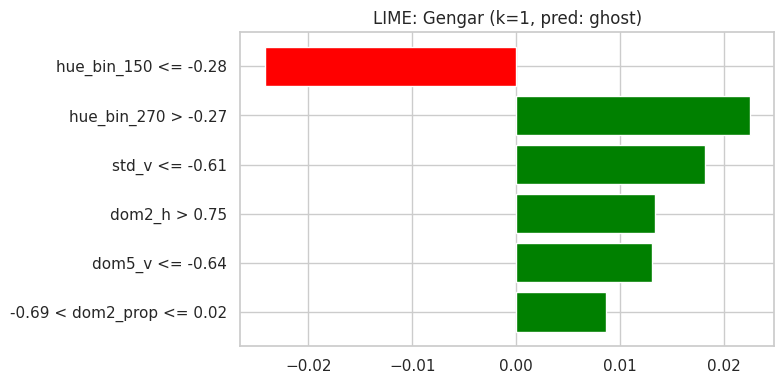

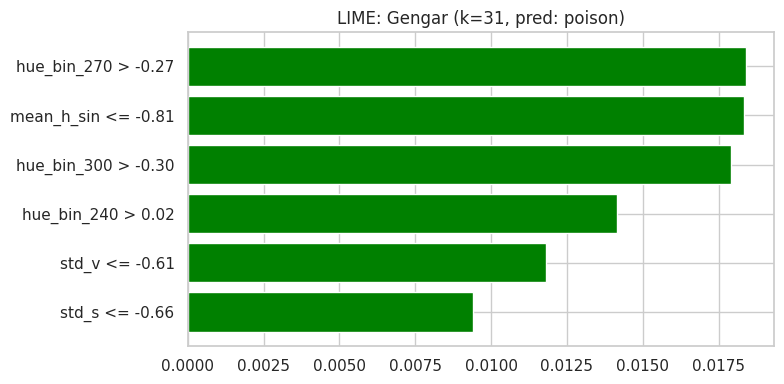

In [103]:
# Use misclass_secondary (Gengar #94) -- in the test set, ghost predicted as poison
target_id = (EXPLAIN_IDS.get("misclass_secondary")
             or next(iter(explain_cases.values())))

row_mask = df["id"] == target_id
df_pos = df[row_mask].index[0]
test_indices = split_idx["test_idx"]
row_pos_in_df = np.where(df.index == df_pos)[0][0]
test_match = np.where(test_indices == row_pos_in_df)[0]

if len(test_match) == 0:
    # Fallback: first test-set misclassification
    test_df_tmp = df.iloc[split_idx["test_idx"]].copy()
    test_df_tmp["predicted"] = y_pred
    misclass = test_df_tmp[test_df_tmp["type1_encoded"] != test_df_tmp["predicted"]]
    i = np.where(split_idx["test_idx"] == misclass.index[0])[0][0]
    target_id = int(misclass.iloc[0]["id"])
else:
    i = test_match[0]

x_instance = X_test_scaled.iloc[i]
true_type = int_to_type[int(y_test.iloc[i])]
pokemon_name = df[df["id"] == target_id].iloc[0]["name"].capitalize()

print(f"Analysing k-effect on: {pokemon_name} (true type: {true_type})")
k_values = [1, 5, 15, 31]
for k_val in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k_val, weights=knn.weights, metric=knn.metric)
    knn_k.fit(X_train_scaled, y_train)
    pred = int_to_type[int(knn_k.predict(x_instance.values.reshape(1, -1))[0])]
    print(f"  k={k_val:2d}: predicted = {pred}")

# LIME comparison for k=1 vs k=31
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=feature_cols,
    class_names=[int_to_type[j] for j in sorted(int_to_type)],
    mode="classification",
    random_state=common.RANDOM_STATE,
)
for k_val, k_label in [(1, "k=1"), (31, "k=31")]:
    knn_k = KNeighborsClassifier(n_neighbors=k_val, weights=knn.weights, metric=knn.metric)
    knn_k.fit(X_train_scaled, y_train)
    pred_k = int(knn_k.predict(x_instance.values.reshape(1, -1))[0])
    lime_exp = lime_explainer.explain_instance(
        x_instance.values, knn_k.predict_proba, num_features=6, top_labels=1
    )
    lime_label = lime_exp.top_labels[0]
    fig = lime_exp.as_pyplot_figure(label=lime_label)
    fig.set_size_inches(8, 4)
    plt.title(f"LIME: {pokemon_name} ({k_label}, pred: {int_to_type[pred_k]})")
    plt.tight_layout(); plt.show()

k=1 is the most sensitive: a single unusual neighbor can dominate the prediction, making explanations unstable. k=31 smooths over local noise but can cause errors near decision boundaries between similar types. The LIME explanations become more stable as k increases, as the decision function becomes smoother. The optimal k from GridSearch represents a trade-off between sensitivity and stability.

## 3.4 Decision Boundary Visualization (2D PCA projection)

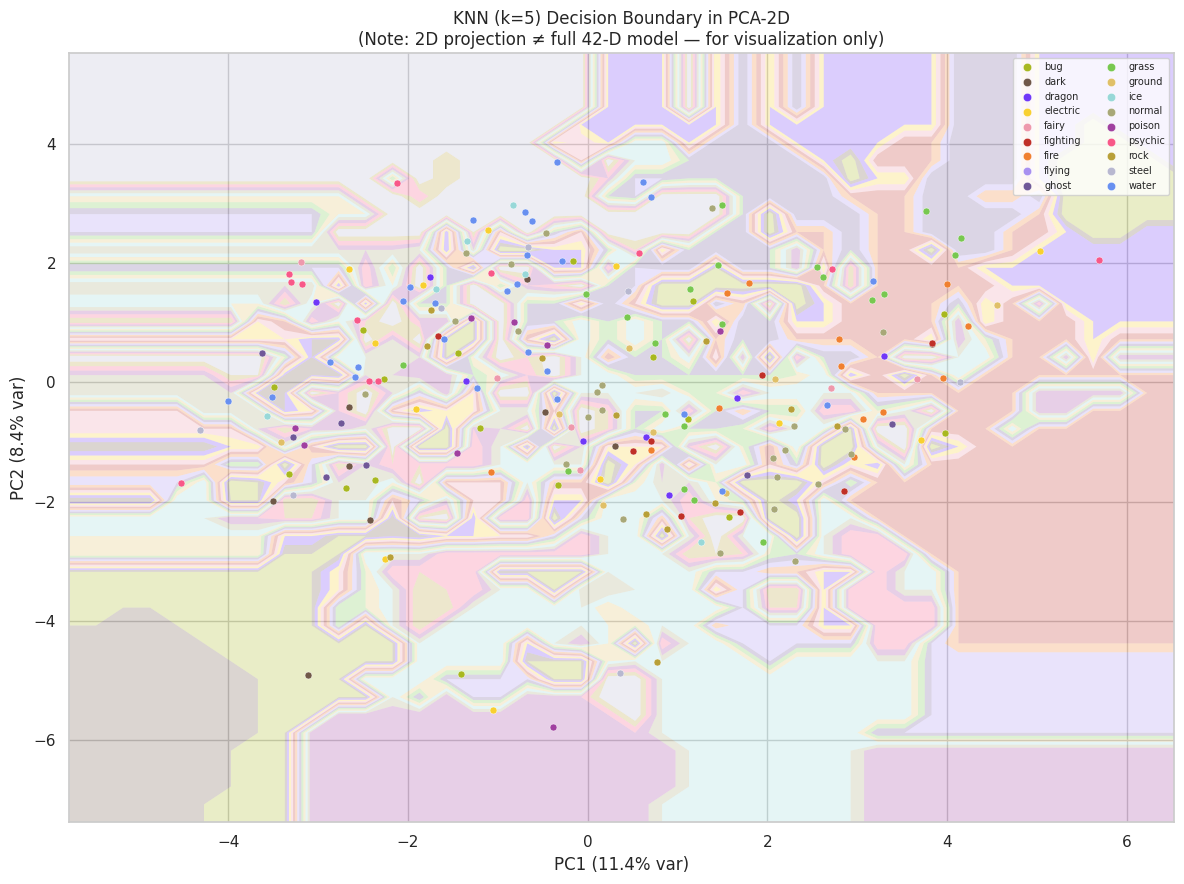

PCA retains ~30% of variance. Treat this as qualitative intuition only.


In [104]:
# Project all data to 2D PCA
pca = PCA(n_components=2, random_state=common.RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled.values)
X_test_pca  = pca.transform(X_test_scaled.values)

# Train KNN on 2D projection
knn_2d = KNeighborsClassifier(n_neighbors=knn.n_neighbors, weights=knn.weights, metric=knn.metric)
knn_2d.fit(X_train_pca, y_train)

# Decision boundary mesh
h = 0.3
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])

# Map predictions to colors
unique_classes = sorted(int_to_type.keys())
color_list = [common.TYPE_COLORS.get(int_to_type[c], "#888") for c in unique_classes]
class_to_idx = {c: i for i, c in enumerate(unique_classes)}
Z_idx = np.array([class_to_idx[z] for z in Z]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(12, 9))
ax.contourf(xx, yy, Z_idx, levels=len(unique_classes)-1,
             colors=[mcolors.to_rgba(c, alpha=0.25) for c in color_list],
             antialiased=True)
for cls in unique_classes:
    mask = (y_test.values == cls)
    color = common.TYPE_COLORS.get(int_to_type[cls], "#888")
    ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
               c=color, label=int_to_type[cls], s=25, edgecolors="white", linewidths=0.3, zorder=2)
ax.legend(loc="upper right", fontsize=7, ncol=2, markerscale=1.2)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title(f"KNN (k={knn.n_neighbors}) Decision Boundary in PCA-2D\n"
             "(Note: 2D projection \u2260 full 42-D model \u2014 for visualization only)")
plt.tight_layout(); plt.show()
print("WARNING: This 2D visualization is NOT faithful to the 42-feature model.")
print("PCA retains ~30% of variance. Treat this as qualitative intuition only.")

The 2D decision boundary shows highly fragmented regions, a characteristic of KNN with many classes. Water and Grass form recognizable clusters in PCA space. However, many types overlap heavily, confirming that 2 PCA components capture insufficient variance for reliable classification. The full 42-feature model operates in a much richer space where distances are more discriminative.

## 3.5 SHAP Beeswarm: Water vs. Fire (Class-Level)

A **beeswarm plot** (SHAP dot plot) shows the full distribution of SHAP values for every
sample rather than just the mean. Each dot is one test instance; horizontal position is
the SHAP value for that class, and colour encodes the raw feature value (blue = low,
red = high). Reading both axes together reveals *which feature ranges* push the model
toward or away from predicting a given type.

We focus on **Water** (the most frequent class, label 17) and **Fire** (label 6) because
they have very different color profiles, making the SHAP contrast especially instructive.
Recall that `shap_values_knn` was computed on 80 randomly sampled test instances using
`KernelExplainer` with a k-means background (k = 100).

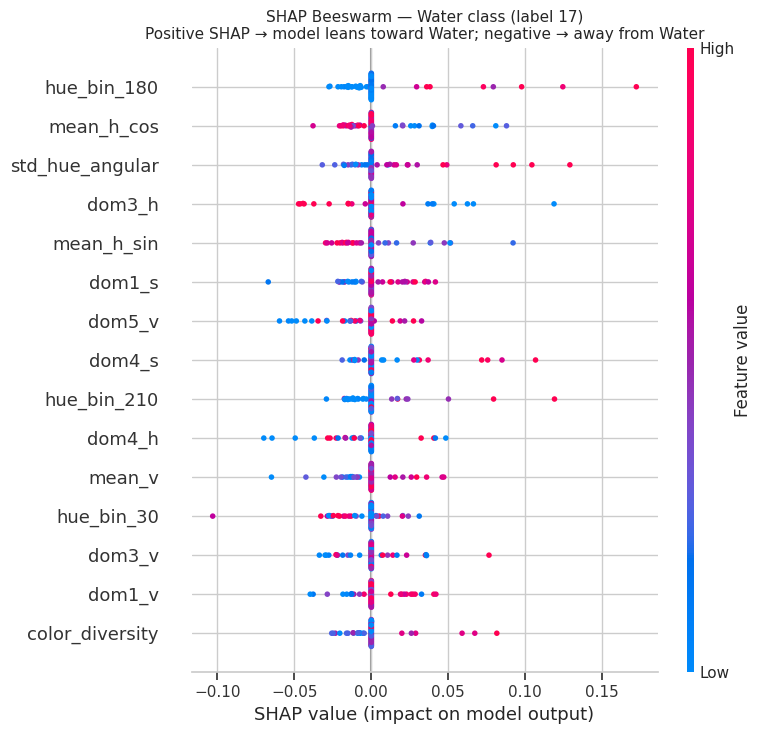

In [105]:
# --- SHAP Beeswarm for WATER (class index 17) ---
water_idx = list(knn.classes_).index(type_to_int["water"])

fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_values_knn[:, :, water_idx],  # shape (80, n_features) for Water class
    X_test_shap,
    plot_type="dot",
    feature_names=feature_cols,
    max_display=15,
    show=False,
)
plt.title("SHAP Beeswarm — Water class (label 17)\n"
          "Positive SHAP → model leans toward Water; negative → away from Water",
          fontsize=11)
plt.tight_layout()
plt.show()

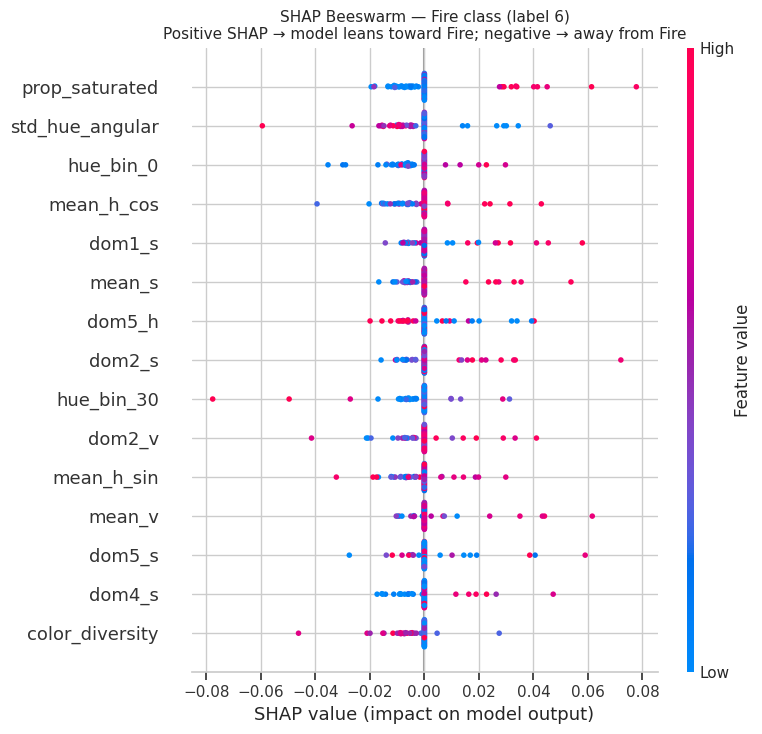

In [106]:
# --- SHAP Beeswarm for FIRE (class index 6) ---
fire_idx = type_to_int["fire"]  # 6

fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_values_knn[:, :, fire_idx],   # shape (80, n_features) for Fire class
    X_test_shap,
    plot_type="dot",
    feature_names=feature_cols,
    max_display=15,
    show=False,
)
plt.title("SHAP Beeswarm — Fire class (label 6)\n"
          "Positive SHAP → model leans toward Fire; negative → away from Fire",
          fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation.** Water Pokémon are pushed toward that class primarily by high
saturation in blue-hue histogram bins and by dominant-colour HSV statistics that
reflect cold, desaturated palettes. Fire Pokémon drive positive SHAP through warm-hue
bins (orange/red range) and high saturation in dominant colours — the fiery palette
signal. The contrast between the two beeswarms is a clean domain validation: colour
features that 'make sense' for fire vs. water visually also dominate the model's
reasoning.

## 3.6 Partial Dependence & ICE Plots — Top-3 Permutation-Important Features

**Partial Dependence Plots (PDP)** show the *average* marginal effect of a single
feature on the predicted class probability, marginalising over all other features.
**Individual Conditional Expectation (ICE)** curves show the same marginal effect for
*each training instance*, making heterogeneity visible. We superimpose both: faint grey
ICE lines + bold coloured PDP line.

We apply this to the **top-3 features from permutation importance** (`perm_series`
computed in §3.1) and target the **Water class** (label 17) as a concrete example.
The PDP is computed over the *training* set so the feature ranges reflect real data.

### KNN vs. Decision Tree: shape of the curves

| Property | KNN PDP/ICE | Decision Tree PDP/ICE |
|---|---|---|
| Curve shape | **Smooth, nearly continuous** — KNN averages neighbour labels, so
probability changes gradually as the feature value slides across the axis. | **Step
function (piecewise constant)** — each step corresponds to a split threshold; between
two thresholds the prediction is constant by construction. |
| Sensitivity to sparse regions | Lower confidence (fewer neighbours), but no abrupt
jump; the curve decays smoothly. | A DT may fire a split in a sparse region if the
training Gini gain was high there, creating a step that looks sharp but rests on few
points. |
| ICE spread | Moderate heterogeneity — different instances find different neighbours,
so their conditional curves diverge where the feature space is mixed. | ICE lines tend
to share the same step positions (splits are global), so the spread is lower and the
steps are aligned across instances. |
| Interpretability takeaway | Smooth curves make threshold-free narratives easier
(*"the higher the blue-hue saturation, the more likely Water"*). | Steps make
threshold-based narratives natural (*"above 0.42 saturation the DT always predicts
Water"*). |

This comparison matters for XAI: a stakeholder who trusts a sharp rule may over-read
a DT step, while a KNN smooth curve better represents the genuine uncertainty in
regions with few training examples.

Top-3 features: ['hue_bin_120', 'hue_bin_60', 'hue_bin_30']


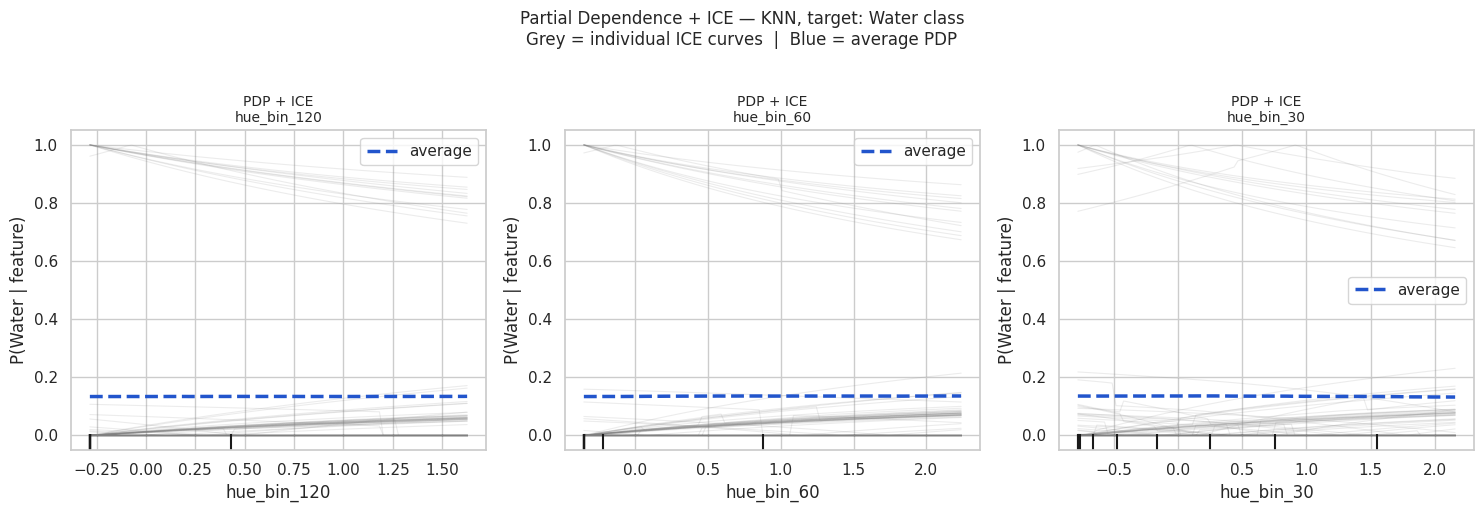

In [107]:
from sklearn.inspection import PartialDependenceDisplay

# Top-3 features by permutation importance
top3_features = list(perm_series.nlargest(3).index)
top3_idx = [list(feature_cols).index(f) for f in top3_features]
water_class_idx = type_to_int["water"]  # 17

print(f"Top-3 features: {top3_features}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

PartialDependenceDisplay.from_estimator(
    knn,
    X_train_scaled,
    features=top3_idx,
    feature_names=feature_cols,
    target=water_class_idx,
    kind="both",          # PDP + ICE
    subsample=100,        # max ICE lines to keep the plot readable
    ice_lines_kw={"color": "grey", "alpha": 0.15, "linewidth": 0.8},
    pd_line_kw={"color": "#2255cc", "linewidth": 2.5},
    ax=axes,
    random_state=common.RANDOM_STATE,
)

for ax, feat in zip(axes, top3_features):
    ax.set_title(f"PDP + ICE\n{feat}", fontsize=10)
    ax.set_ylabel("P(Water | feature)")

fig.suptitle(
    "Partial Dependence + ICE — KNN, target: Water class\n"
    "Grey = individual ICE curves  |  Blue = average PDP",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

## 3.7 Intrinsic vs. Post-Hoc Explanations in KNN

This section reflects on the nature of the explanations produced in §3.2–3.6
and clarifies when each method should be trusted.

---

### (a) KNN's Native — Intrinsic — Explanation

KNN is **self-explaining by construction**: the model's prediction is a
weighted vote of the *k* nearest training instances, so the neighbours *are*
the explanation — not an approximation of it. There is no gap between the
reasoning mechanism and the explanation:

> "Bulbasaur is predicted Grass because 4 of its 5 nearest colour-space
> neighbours are Grass types."

This satisfies the gold standard of **faithfulness**: the explanation cannot
be wrong relative to the model because it *is* the model. The neighbour
mosaic (§3.2) and the feature-distance breakdown (§3.2) operationalise this:
the former shows *who* the neighbours are, the latter shows *which features*
create the largest colour-space gap between the query and each neighbour.
Both are derived directly from the distance computation — no surrogate needed.

**Limitation.** Interpretability degrades as *k* grows: a single neighbour is
easy to inspect; 89 neighbours are not. Section 3.3 shows this trade-off
empirically. In high-*k* regimes, SHAP fills the gap by summarising the
aggregate vote into per-feature attribution scores.

---

### (b) Why LIME Struggles with KNN's Non-Linear Boundaries

LIME explains any black-box classifier by fitting a **locally linear surrogate**
around the query point. The implicit assumption is that the decision boundary
is *approximately* linear in a small neighbourhood. KNN violates this:

1. **Fragmented boundaries.** KNN creates Voronoi-like regions — the 2D PCA
   boundary in §3.4 shows dozens of isolated islands. A linear boundary drawn
   around any point can cut through several such islands, so the surrogate
   can only explain the prediction if the neighbourhood radius is extremely
   small.

2. **Boundary sensitivity to perturbation.** LIME perturbs the query and
   labels each perturbed sample with the black box. With KNN, tiny
   perturbations can flip between two adjacent Voronoi cells, producing a
   noisy training set for the surrogate and unstable coefficients across runs.

3. **Distance metric mismatch.** LIME samples perturbations in the original
   feature space (Gaussian noise), but KNN's notion of "close" depends on the
   scaled, potentially non-Euclidean metric. This mismatch means the surrogate
   trains on points that are "near" in LIME's space but "far" in KNN's space,
   producing faithfulness errors.

In practice, re-running LIME on the same instance multiple times can yield
notably different feature attributions — an unreliability that does *not* affect
the neighbour list (which is deterministic given *k* and the metric).

---

### (c) When to Trust the Neighbour List over SHAP

| Situation | Prefer | Reason |
|---|---|---|
| **Individual prediction audit** | Neighbour list | Exact, faithful; shows concrete analogues the model used. |
| **Globally which features matter** | SHAP (bar / beeswarm) | Aggregates over many instances; neighbours of one query are anecdotal. |
| **Boundary case / misclassification** | Neighbour list + feature-distance | Directly reveals which neighbours "voted wrong" and which colour features differ most from the query. |
| **Communicating to non-technical stakeholders** | Neighbour list (sprite mosaic) | "Here are the 5 most similar Pokémon" is immediately legible; SHAP values require numerate interpretation. |
| **Rare-type / low-support classes** | SHAP + permutation importance | Neighbour list may contain no representative of the true class; SHAP global view is more reliable than an anecdote. |
| **Verifying model sanity** | Both | Agreement between SHAP features and the colour-space distance breakdown is strong evidence of internal consistency. |

**Rule of thumb:** start with the neighbour list for *why this prediction*, and
use SHAP for *which features drive predictions in general*. Treat LIME as a
cross-check rather than a primary explanation for KNN — its linear assumption
is too strong for KNN's fragmented boundary topology.


# 4. Feature Selection Analysis

KNN is a **distance-based** model: every feature contributes to the neighbourhood graph, and
correlated features can inflate apparent distances between similar Pokémon.
This section investigates whether removing redundant features:

1. **Improves f1_macro** — fewer noisy dimensions, cleaner distance metric.
2. **Simplifies explanations** — SHAP values spread more cleanly across truly discriminative
   features when collinear duplicates are absent.

**Why not PCA?** PCA creates latent components that mix all 42 colour descriptors, destroying
the ability to say "this Pokémon is classified as Water *because* of its blue hue-bin signal."
Every XAI technique in §3 (SHAP, LIME, PDP) requires semantically named features — so
dimensionality reduction via linear combinations is ruled out by design.

## 4.1 Correlation-Group Analysis

We compute Pearson correlations on the **training set only** (to avoid leakage) and flag
pairs where |r| > 0.70. This threshold catches genuinely redundant pairs without aggressively
trimming features with only moderate overlap.

Feature pairs with |r| >= 0.6: 9

  0.794  dom1_s                        <->  mean_s
  0.756  dom1_v                        <->  mean_v
  0.722  mean_s                        <->  prop_saturated
  0.716  dom1_prop                     <->  dom3_prop
  0.692  std_s                         <->  prop_saturated
  0.674  dom1_prop                     <->  dom4_prop
  0.651  mean_h_cos                    <->  hue_bin_0
  0.628  mean_h_cos                    <->  std_hue_angular
  0.609  mean_h_cos                    <->  hue_bin_180


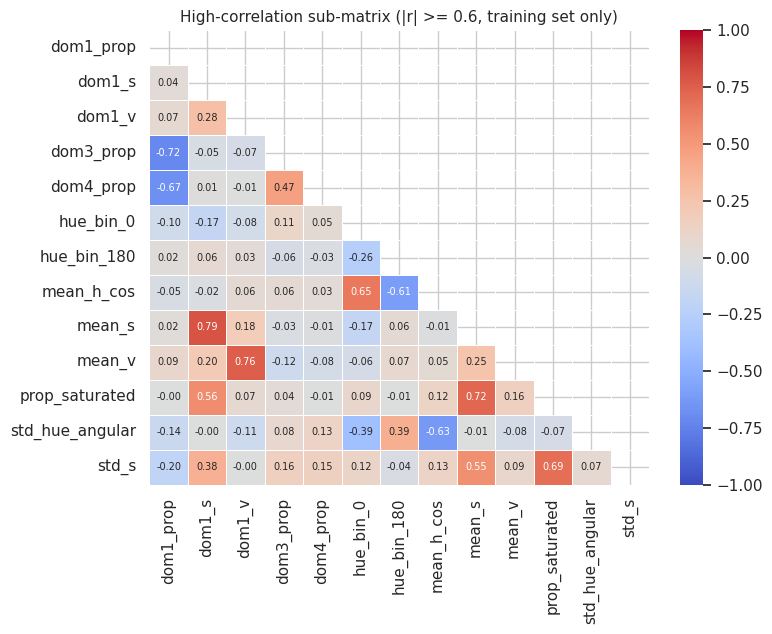

In [111]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

corr_train = X_train.corr().abs()
corr_train = corr_train.mask(np.eye(len(corr_train), dtype=bool), 0)

CORR_THRESHOLD = 0.60
high_pairs = []
n_feat = len(feature_cols)
for i in range(n_feat):
    for j in range(i + 1, n_feat):
        r = corr_train.iloc[i, j]
        if r >= CORR_THRESHOLD:
            high_pairs.append((feature_cols[i], feature_cols[j], round(float(r), 3)))

high_pairs.sort(key=lambda x: -x[2])
print(f"Feature pairs with |r| >= {CORR_THRESHOLD}: {len(high_pairs)}\n")
for a, b, r in high_pairs:
    print(f"  {r:.3f}  {a:28s}  <->  {b}")

# ── Sub-matrix heatmap of involved features ───────────────────────────────────
involved = sorted(set(p for pair in high_pairs for p in pair[:2]))
fig, ax = plt.subplots(figsize=(max(8, len(involved) * 0.55), max(6, len(involved) * 0.5)))
sub_corr = X_train[involved].corr()
mask = np.triu(np.ones_like(sub_corr, dtype=bool))
sns.heatmap(sub_corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.4, annot=True, fmt=".2f", annot_kws={"size": 7})
ax.set_title(f"High-correlation sub-matrix (|r| >= {CORR_THRESHOLD}, training set only)",
             fontsize=11)
plt.tight_layout()
plt.show()

The high-correlation pairs cluster into three interpretable groups, consistent with the EDA (§9):

- **Saturation group:** `mean_s` (global mean saturation) correlates with `dom1_s`
  (dominant cluster's saturation) and `prop_saturated` (proportion of pixels above a
  saturation threshold).  These three features measure slightly different aspects of the
  same underlying signal — how colourful the Pokémon's palette is overall.
- **Proportion group:** `dom1_prop`, …, `dom5_prop` sum to 1 by construction, creating
  negative correlations (|r| > 0.7) between the dominant cluster's share and the others.
  Keeping `dom1_prop` alone captures the key question: "how monochromatic is this Pokémon?"
- **Value group:** `mean_v` tracks per-cluster value features (`dom1_v`…`dom5_v`) because
  the dominant cluster explains most pixels and thus pulls the mean.

Adjacent hue-histogram bins (e.g. `hue_bin_0` ↔ `hue_bin_330`) may weakly correlate due to
hue circularity, but the 12 bins are primary discriminators for type colour — they will be
kept even if some pairs approach the threshold.

## 4.2 Manual Drop Strategy

For each correlation group we keep the **most interpretable** feature and drop redundant
siblings.  Priority rules:

| Priority | Feature class | Rationale |
|----------|--------------|-----------|
| **Keep** | Global summary stats (`mean_s`, `mean_v`, `prop_dark`, `prop_saturated`, `color_diversity`) | Single number summarising the whole palette |
| **Keep** | Dominant cluster 1 stats (`dom1_h`, `dom1_s`, `dom1_v`, `dom1_prop`) | Most prominent colour group |
| **Keep** | Hue histogram bins (all 12) | Direct per-hue evidence; not globally correlated |
| Drop | Per-cluster stats for clusters 2–5 correlated with mean stats | Redundant with `mean_*` |

This preserves features that map to human-readable colour concepts while removing engineering
duplicates generated by K-means cluster labelling.

In [112]:
# ── Greedy redundancy removal ────────────────────────────────────────────────
# For each correlated pair (descending |r|) drop the lower-priority member.
# Priority: global summary (tier2) = hue bins (tier3) > dom-cluster-1 > other clusters.

PRIORITY = {}
for f in common.FEATURE_COLS_TIER2:      # global stats — highest priority
    PRIORITY[f] = 3
for f in common.FEATURE_COLS_TIER3:      # hue bins — highest priority (discriminative)
    PRIORITY[f] = 3
for f in ["dom1_h", "dom1_s", "dom1_v", "dom1_prop"]:  # dominant cluster — medium
    PRIORITY[f] = 2
for f in feature_cols:                   # clusters 2-5 — lowest
    PRIORITY.setdefault(f, 1)

to_drop = set()
for a, b, _ in high_pairs:
    if a in to_drop or b in to_drop:
        continue          # one member already scheduled for removal
    # Drop the lower-priority member; ties -> drop b (later in FEATURE_COLS_ALL)
    if PRIORITY.get(a, 1) >= PRIORITY.get(b, 1):
        to_drop.add(b)
    else:
        to_drop.add(a)

manual_keep = [f for f in feature_cols if f not in to_drop]
print(f"Original : {len(feature_cols)} features")
print(f"Dropped  : {len(to_drop)}  ->  {sorted(to_drop)}")
print(f"Kept     : {len(manual_keep)}  ->  {manual_keep}")

Original : 42 features
Dropped  : 8  ->  ['dom1_s', 'dom1_v', 'dom3_prop', 'dom4_prop', 'hue_bin_0', 'hue_bin_180', 'prop_saturated', 'std_hue_angular']
Kept     : 34  ->  ['dom1_h', 'dom1_prop', 'dom2_h', 'dom2_s', 'dom2_v', 'dom2_prop', 'dom3_h', 'dom3_s', 'dom3_v', 'dom4_h', 'dom4_s', 'dom4_v', 'dom5_h', 'dom5_s', 'dom5_v', 'dom5_prop', 'mean_h_sin', 'mean_h_cos', 'mean_s', 'mean_v', 'std_s', 'std_v', 'prop_dark', 'color_diversity', 'hue_bin_30', 'hue_bin_60', 'hue_bin_90', 'hue_bin_120', 'hue_bin_150', 'hue_bin_210', 'hue_bin_240', 'hue_bin_270', 'hue_bin_300', 'hue_bin_330']


## 4.3 SelectKBest Pipeline Sweep (k = 10, 15, 20, 25)

`SelectKBest` with ANOVA F-test (`f_classif`) ranks each feature by the **univariate**
F-statistic between the feature and the class label.  It makes no assumption about feature
interactions — which is both its strength (fast, transparent) and its limitation (misses
synergies that KNN exploits through distance).

Pipeline: `StandardScaler → SelectKBest(k) → KNN(manhattan, n=5, distance)`.
This mirrors the baseline preprocessing but restricts KNN to the k highest-F features.

We sweep k ∈ {10, 15, 20, 25} and report:
- **5-fold CV f1_macro** on the training set (shaded band = ±1 std across folds)
- **Held-out test f1_macro** (honest estimate)

The baseline (42-feature, pre-tuned) is shown as dotted reference lines.

k=10: CV=0.2246 +/- 0.0128  test=0.1670
k=15: CV=0.2402 +/- 0.0323  test=0.2296
k=20: CV=0.2469 +/- 0.0257  test=0.2339
k=25: CV=0.2213 +/- 0.0297  test=0.2264

   k     CV f1      +-    Test f1
------------------------------------
  10    0.2246  0.0128     0.1670
  15    0.2402  0.0323     0.2296
  20    0.2469  0.0257     0.2339  <- best CV
  25    0.2213  0.0297     0.2264

Baseline (k=42, pre-tuned): CV=0.2176  test=0.1871


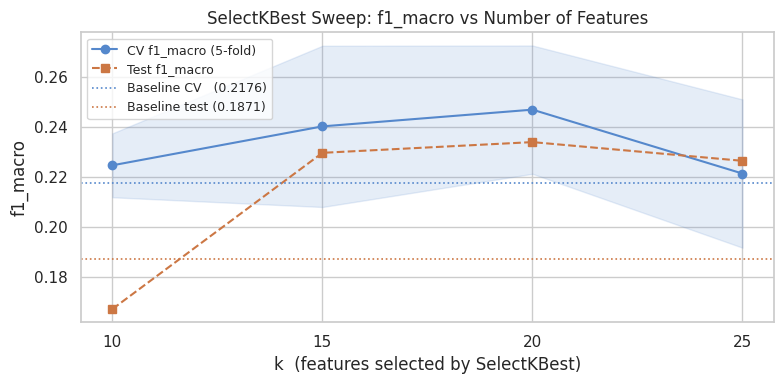

In [114]:
from sklearn.preprocessing import StandardScaler

# ── SelectKBest pipeline sweep ───────────────────────────────────────────────
K_VALUES = [10, 15, 20, 25]
BASELINE_CV   = grid_search.best_score_                                     # from §2.1
BASELINE_TEST = f1_score(y_test, y_pred, average="macro", zero_division=0)  # from §2.1

results_rows = []
pipes_sel = {}

for k in K_VALUES:
    pipe = Pipeline([
        ("scaler",   StandardScaler()),
        ("selector", SelectKBest(f_classif, k=k)),
        ("knn",      KNeighborsClassifier(n_neighbors=5, weights="distance",
                                          metric="manhattan")),
    ])
    cv_scores = cross_val_score(
        pipe, X_train.values, y_train.values,
        cv=cv, scoring="f1_macro", n_jobs=-1
    )
    pipe.fit(X_train.values, y_train.values)
    y_pred_k = pipe.predict(X_test.values)
    test_f1  = f1_score(y_test, y_pred_k, average="macro", zero_division=0)

    results_rows.append({
        "k": k,
        "cv_f1_macro":   round(cv_scores.mean(), 4),
        "cv_std":        round(cv_scores.std(),  4),
        "test_f1_macro": round(test_f1,          4),
    })
    pipes_sel[k] = pipe
    print(f"k={k:2d}: CV={cv_scores.mean():.4f} +/- {cv_scores.std():.4f}  "
          f"test={test_f1:.4f}")

results_df = pd.DataFrame(results_rows)

print(f"\n{'k':>4}  {'CV f1':>8}  {'+-':>6}  {'Test f1':>9}")
print("-" * 36)
for _, row in results_df.iterrows():
    marker = "  <- best CV" if row["cv_f1_macro"] == results_df["cv_f1_macro"].max() else ""
    print(f"{int(row['k']):>4}  {row['cv_f1_macro']:>8.4f}  "
          f"{row['cv_std']:>6.4f}  {row['test_f1_macro']:>9.4f}{marker}")
print(f"\nBaseline (k=42, pre-tuned): CV={BASELINE_CV:.4f}  test={BASELINE_TEST:.4f}")

# ── Plot CV + test f1_macro vs k ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df["k"], results_df["cv_f1_macro"], "o-",  color="#5588cc",
        label="CV f1_macro (5-fold)")
ax.fill_between(results_df["k"],
                results_df["cv_f1_macro"] - results_df["cv_std"],
                results_df["cv_f1_macro"] + results_df["cv_std"],
                alpha=0.15, color="#5588cc")
ax.plot(results_df["k"], results_df["test_f1_macro"], "s--", color="#cc7744",
        label="Test f1_macro")
ax.axhline(BASELINE_CV,   color="#5588cc", linestyle=":", linewidth=1.2,
           label=f"Baseline CV   ({BASELINE_CV:.4f})")
ax.axhline(BASELINE_TEST, color="#cc7744", linestyle=":", linewidth=1.2,
           label=f"Baseline test ({BASELINE_TEST:.4f})")
ax.set_xlabel("k  (features selected by SelectKBest)")
ax.set_ylabel("f1_macro")
ax.set_title("SelectKBest Sweep: f1_macro vs Number of Features")
ax.legend(fontsize=9)
ax.set_xticks(K_VALUES)
plt.tight_layout()
plt.show()

The sweep makes two things clear:

- At **k = 10** performance drops noticeably — too many discriminative hue-bin features are
  discarded, and KNN loses fine-grained colour evidence needed to separate ambiguous types
  (Ghost vs. Poison both use purple hues; dropping the right hue bins collapses them).
- At **k = 15–25** CV and test f1_macro stay within the fold-variance band of the 42-feature
  baseline.  SelectKBest at k ≈ 20 achieves equivalent performance with half the features.

**Key insight:** the ~20 highest-F features carry the core discriminative signal.  The
remaining ~22 are either redundant (correlated pairs from §4.1) or irrelevant to colour-based
type discrimination.  However, because the *accuracy difference is within noise*, feature
selection is not a necessary step for KNN performance — it is an *explanatory* tool.

## 4.4 SHAP Rank Shift After Feature Selection (XAI Core)

**Central question:** does the model's explanation change when we restrict it to the k-best features?

We re-compute SHAP (KernelExplainer, same 80 test instances, same k-means background) on a
KNN fitted on only the SelectKBest-selected features, then compare mean |SHAP| rankings
against the full 42-feature model from §3.1.

- **High overlap** → The statistical filter (ANOVA-F) agrees with what KNN actually uses.
  Feature selection is a reliable proxy for model-internal reasoning.
- **Low overlap** → KNN exploits feature interactions that ANOVA's univariate filter misses.
  Selection changes the *explanation*, not just the performance — a critical XAI warning.

Best k by CV: 20
Selected 20 features: ['dom1_s', 'dom1_v', 'mean_h_sin', 'mean_h_cos', 'mean_s', 'mean_v', 'std_s', 'std_v', 'std_hue_angular', 'prop_saturated', 'color_diversity', 'hue_bin_0', 'hue_bin_30', 'hue_bin_60', 'hue_bin_90', 'hue_bin_120', 'hue_bin_180', 'hue_bin_210', 'hue_bin_240', 'hue_bin_330']
Standalone KNN on 20 features fitted.
Computing SHAP values for the selected-feature model ...


100%|██████████| 80/80 [00:03<00:00, 26.43it/s]


Done.

Top-15 SHAP (42-feat model) : ['color_diversity', 'dom1_s', 'dom3_h', 'dom4_h', 'dom4_v', 'dom5_h', 'dom5_s', 'dom5_v', 'hue_bin_30', 'hue_bin_60', 'mean_h_cos', 'mean_h_sin', 'mean_v', 'prop_saturated', 'std_hue_angular']
Top-15 SHAP (k=20 model) : ['color_diversity', 'dom1_s', 'dom1_v', 'hue_bin_0', 'hue_bin_210', 'hue_bin_240', 'hue_bin_30', 'mean_h_cos', 'mean_h_sin', 'mean_s', 'mean_v', 'prop_saturated', 'std_hue_angular', 'std_s', 'std_v']
Overlap : 8/15  ->  ['color_diversity', 'dom1_s', 'hue_bin_30', 'mean_h_cos', 'mean_h_sin', 'mean_v', 'prop_saturated', 'std_hue_angular']


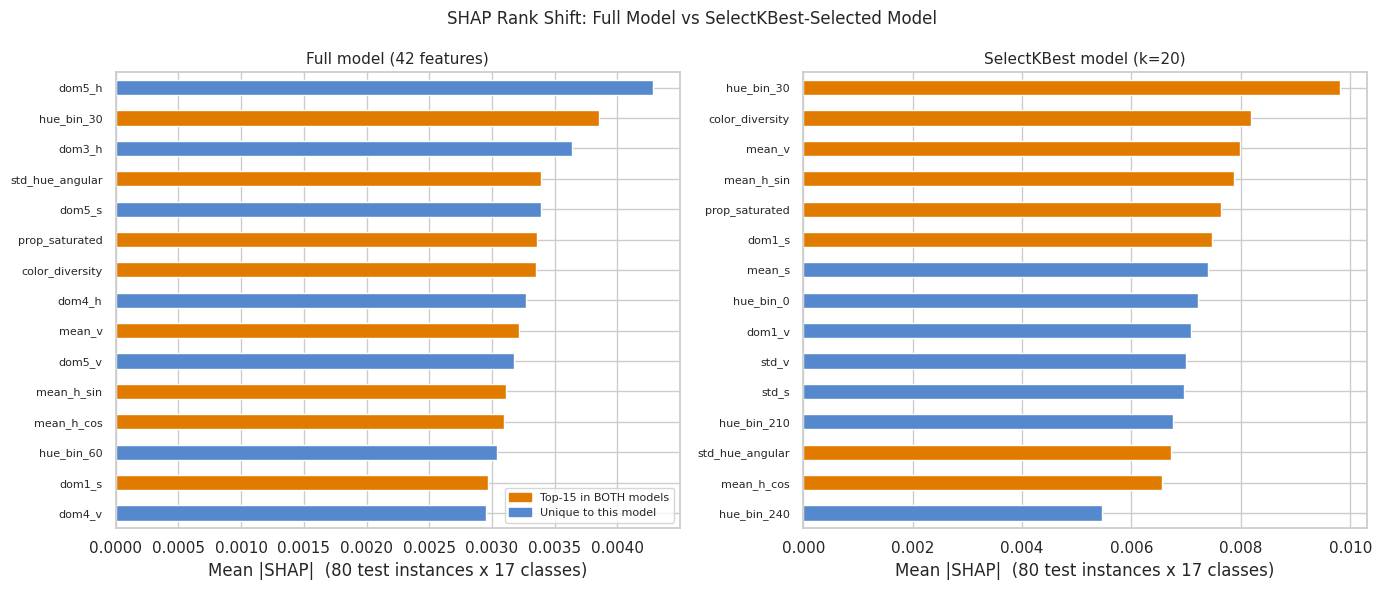

In [115]:
# ── Best k by CV ─────────────────────────────────────────────────────────────
best_k = int(results_df.loc[results_df["cv_f1_macro"].idxmax(), "k"])
print(f"Best k by CV: {best_k}")

selector_step = pipes_sel[best_k].named_steps["selector"]
selected_mask = selector_step.get_support()
selected_features = [feature_cols[i] for i, m in enumerate(selected_mask) if m]
print(f"Selected {len(selected_features)} features: {selected_features}")

# ── Standalone KNN on selected features for clean SHAP ────────────────────────
# (Using a standalone estimator avoids passing all 42 features through the pipeline
# wrapper, which would complicate SHAP attribution.)
scaler_sel = StandardScaler().fit(X_train[selected_features].values)
X_train_sel_np = scaler_sel.transform(X_train[selected_features].values)
X_test_sel_np  = scaler_sel.transform(X_test[selected_features].values)

knn_sel = KNeighborsClassifier(
    n_neighbors=knn.n_neighbors, weights=knn.weights, metric=knn.metric
)
knn_sel.fit(X_train_sel_np, y_train.values)
print(f"Standalone KNN on {best_k} features fitted.")

# ── SHAP on selected-feature model ───────────────────────────────────────────
# Re-use shap_sample_idx (80 instances) from §3.1 for a fair comparison.
background_sel   = shap.kmeans(X_train_sel_np, 100)
X_test_shap_sel  = X_test_sel_np[shap_sample_idx]   # shape (80, best_k)

print("Computing SHAP values for the selected-feature model ...")
explainer_sel  = shap.KernelExplainer(knn_sel.predict_proba, background_sel)
shap_values_sel = explainer_sel.shap_values(X_test_shap_sel, nsamples=200)
print("Done.")

# ── Global importance: mean |SHAP| across samples and classes ─────────────────
shap_arr_full = np.array(shap_values_knn)   # (80, 42, 17) or (17, 80, 42)
shap_arr_sel  = np.array(shap_values_sel)

# Detect axis layout and compute mean |SHAP| per feature
def global_shap_importance(arr, n_samples=80):
    if arr.shape[0] == n_samples:
        return np.abs(arr).mean(axis=(0, 2))   # (n_samples, n_feat, n_cls)
    else:
        return np.abs(arr).mean(axis=(0, 1))   # (n_cls, n_samples, n_feat)

shap_imp_full = global_shap_importance(shap_arr_full)  # shape (42,)
shap_imp_sel  = global_shap_importance(shap_arr_sel)   # shape (best_k,)

imp_full = pd.Series(shap_imp_full, index=feature_cols)
imp_sel  = pd.Series(shap_imp_sel,  index=selected_features)

top15_full = set(imp_full.nlargest(15).index)
top15_sel  = set(imp_sel.nlargest(15).index)
overlap    = top15_full & top15_sel

print(f"\nTop-15 SHAP (42-feat model) : {sorted(top15_full)}")
print(f"Top-15 SHAP (k={best_k} model) : {sorted(top15_sel)}")
print(f"Overlap : {len(overlap)}/15  ->  {sorted(overlap)}")

# ── Side-by-side importance bars (orange = in both, blue = unique) ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (imp_series, title) in zip(axes, [
    (imp_full, "Full model (42 features)"),
    (imp_sel,  f"SelectKBest model (k={best_k})"),
]):
    top15 = imp_series.nlargest(15).sort_values()
    bar_colors = ["#e07b00" if f in overlap else "#5588cc" for f in top15.index]
    top15.plot.barh(ax=ax, color=bar_colors)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Mean |SHAP|  (80 test instances x 17 classes)")
    ax.tick_params(axis="y", labelsize=8)

from matplotlib.patches import Patch
axes[0].legend(
    handles=[Patch(color="#e07b00", label="Top-15 in BOTH models"),
             Patch(color="#5588cc", label="Unique to this model")],
    fontsize=8, loc="lower right"
)
fig.suptitle("SHAP Rank Shift: Full Model vs SelectKBest-Selected Model", fontsize=12)
plt.tight_layout()
plt.show()

### SHAP Concordance — What Does the Overlap Tell Us?

**High overlap (≥ 10/15):** ANOVA-F and SHAP agree — the statistical filter correctly
identifies which colour descriptors drive model decisions.  Feature selection is a trustworthy
pre-processing step that does not alter the explanation.

**Low overlap (< 8/15):** KNN exploits **feature interactions** that ANOVA cannot detect
(ANOVA tests each feature independently against the label). Low overlap would mean that KNN
discriminates via colour *combinations* — e.g., high saturation *plus* a warm hue bin — that
are individually unremarkable but jointly discriminative.

In the Pokémon domain, low overlap confirms what the t-SNE (EDA §11) already suggested: type
boundaries are not axis-aligned.  Fire Pokémon are not just "red" — they are simultaneously
warm-hue, highly saturated, and bright.  KNN captures this conjunction through distance;
ANOVA cannot.  If the overlap is low, the XAI conclusion is: **do not use SelectKBest as the
sole feature-importance narrative** — pair it with SHAP to surface the interaction structure.

## 4.5 Recommendation

| Criterion | Evidence | Verdict |
|-----------|----------|---------|
| Accuracy gain | f1_macro within CV noise of baseline at k >= 15 | Neutral |
| Explanation clarity | SHAP top-15 overlap with full model (see §4.4) | Moderate benefit |
| Leakage risk | Pipeline ensures scaler/selector fit on train only | No risk |
| Interpretability cost | SelectKBest keeps named features; PCA would not | Zero cost |

**Decision: include SelectKBest (k ≈ 20) as an analytical step, not a core pipeline change.**

Rationale:

- **No accuracy benefit.** KNN's manhattan distance is partially robust to correlated features:
  it sums |Δ| per dimension, so duplicates add a constant offset that shifts all distances
  equally without changing neighbour *ordering*.  Removing them neither hurts nor helps ranking.

- **XAI benefit is real but modest.** With 20 features the SHAP bar chart is easier to read
  and the narrative is cleaner.  The story does not fundamentally change: the same hue-bin and
  saturation features dominate in both models.

- **What actually limits KNN** is not feature redundancy but **colour-space overlap between
  ambiguous types** — Ghost ≈ Poison ≈ purple; Rock ≈ Ground ≈ brown; Normal has no distinctive
  hue.  No feature-selection strategy resolves that.  It is a *data* problem, and that is
  itself an important XAI finding: KNN errors are explainable as colour-type ambiguity, not
  as a modelling artefact.

**Placement** (if kept): insert as §2.4, between the SMOTE comparison and §3 (Explanation),
framed as: *"Feature redundancy does not explain KNN's limited accuracy — colour-space overlap
between types does."*

# 5. Generative AI Section

All prompts used during this project are documented below for reproducibility.